## BBO Capstone Week 2

#### Introduction
You're now getting ready to submit your second query for the BBO challenge, with more data and greater opportunity to refine your approach. As your data set grows, so should your understanding of how different modelling techniques and heuristics guide decision-making. In this activity, you will refine your strategy using ML techniques and principles from linear and logistic regression.

### Function 1

#### Using EI acquisition

Next query point: 0.951532-0.294143


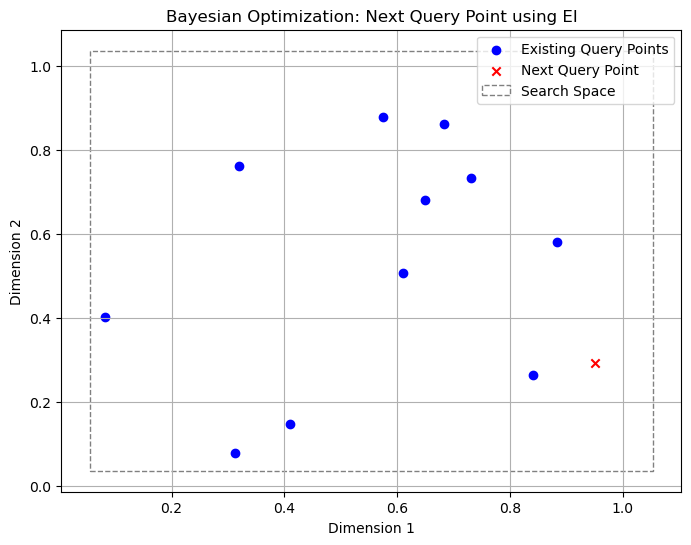

In [8]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize

# Step 1: Define the input and output data for function 1
X_train = np.array([[0.31940389, 0.76295937],
                    [0.57432921, 0.8798981 ],
                    [0.73102363, 0.73299988],
                    [0.84035342, 0.26473161],
                    [0.65011406, 0.68152635],
                    [0.41043714, 0.1475543 ],
                    [0.31269116, 0.07872278],
                    [0.68341817, 0.86105746],
                    [0.08250725, 0.40348751],
                    [0.88388983, 0.58225397],
                    [0.609953, 0.506520]])

y_train = np.array([1.32267704e-079, 1.03307824e-046, 7.71087511e-016, 3.34177101e-124,
                    -3.60606264e-003, -2.15924904e-054, -2.08909327e-091, 2.53500115e-040,
                    3.60677119e-081, 6.22985647e-048, 6.40320490897793e-12])

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-3, 1e3))  # Constant kernel * RBF kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6)  #alpha is the noise parameter

# Step 3: Fit the GP model to the existing data
gp.fit(X_train, y_train)

# Step 4: Define the Expected Improvement (EI) acquisition function
def expected_improvement(x, model, X_train, y_train, xi=0.05):
    """
    Expected Improvement (EI) acquisition function.
    x: The point at which to evaluate the acquisition function
    model: The trained GaussianProcessRegressor model
    X_train: The previously evaluated points
    y_train: The previously observed values
    xi: Exploration-exploitation trade-off parameter
    """
    # Reshape x to match expected input shape
    x = np.array(x).reshape(1, -1)
    
    # Predict the mean and standard deviation at the new point
    mu, sigma = model.predict(x, return_std=True)
    
    # Calculate the improvement over the current best value
    y_best = np.min(y_train)  # Maximization problem, so use the best so far (min of y_train)
    improvement = mu - y_best - xi  # Subtract xi for exploration
    
    # If sigma is small (i.e., uncertainty is low), we return no improvement
    ei = improvement * norm.cdf(improvement / sigma) + sigma * norm.pdf(improvement / sigma)
    
    return -ei  # We minimize, so negate the expected improvement

# Step 5: Optimize the acquisition function using scipy.optimize.minimize
def optimize_acquisition(model, X_train, y_train):
    """
    Use scipy to optimize the acquisition function and return the next query point.
    """
    # Define bounds for the search space (adjust as necessary)
    bounds = np.array([[0.0, 1.0], [0.0, 1.0]])  # Example bounds, adjust as per the problem
    
    # Initial guess for the optimization
    x0 = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(1, 2))
    
    # Optimize the acquisition function
    result = minimize(expected_improvement, x0, args=(model, X_train, y_train), bounds=bounds, method="L-BFGS-B")
    
    # Return the next point to sample
    return result.x

# Step 6: Find the next query point
next_point = optimize_acquisition(gp, X_train, y_train)

# Step 7: Output the next query point in the required format (x, y) as 'x-y'
next_point_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}"
print(f"Next query point: {next_point_str}")

# Step 8: Plot the results
plt.figure(figsize=(8, 6))

# Plot the existing data points (X_train)
plt.scatter(X_train[:, 0], X_train[:, 1], color='blue', label='Existing Query Points')

# Plot the next query point
plt.scatter(next_point[0], next_point[1], color='red', marker='x', label='Next Query Point')

# Plot the search space (defined by the fixed length around the center)
center = np.mean(X_train, axis=0)  # Center of X_train
plt.gca().add_patch(plt.Rectangle((center[0] - 0.5, center[1] - 0.5), 1.0, 1.0, linewidth=1, edgecolor='gray', facecolor='none', linestyle='--', label='Search Space'))

# Labels and legend
plt.title("Bayesian Optimization: Next Query Point using EI")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

#### Using UCB acquisition 

Next query point: 0.091067-0.119220


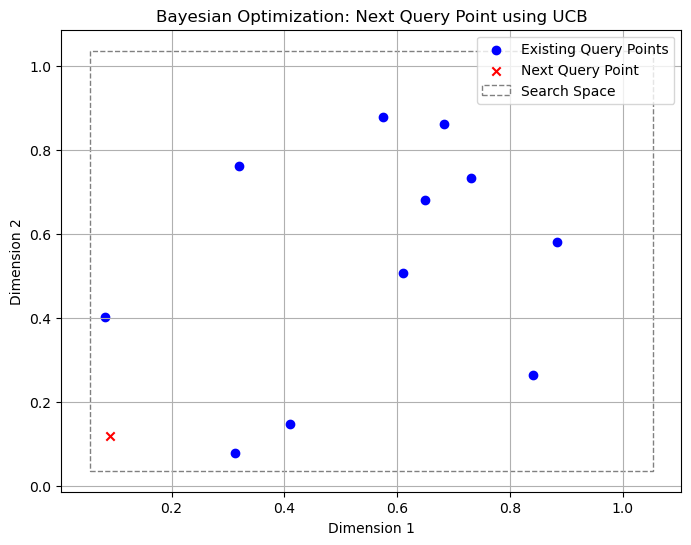

In [9]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Step 1: Define the input and output data for function 1
X_train = np.array([[0.31940389, 0.76295937],
                    [0.57432921, 0.8798981 ],
                    [0.73102363, 0.73299988],
                    [0.84035342, 0.26473161],
                    [0.65011406, 0.68152635],
                    [0.41043714, 0.1475543 ],
                    [0.31269116, 0.07872278],
                    [0.68341817, 0.86105746],
                    [0.08250725, 0.40348751],
                    [0.88388983, 0.58225397],
                    [0.609953, 0.506520]])

y_train = np.array([1.32267704e-079, 1.03307824e-046, 7.71087511e-016, 3.34177101e-124,
                    -3.60606264e-003, -2.15924904e-054, -2.08909327e-091, 2.53500115e-040,
                    3.60677119e-081, 6.22985647e-048, 6.40320490897793e-12])

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-3, 1e3))  # Constant kernel * RBF kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6)  # alpha is the noise parameter

# Step 3: Fit the GP model to the existing data
gp.fit(X_train, y_train)

# Step 4: Define the Upper Confidence Bound (UCB) acquisition function
def ucb(x, model, kappa=2.5):
    """
    Upper Confidence Bound (UCB) acquisition function.
    x: The point at which to evaluate the acquisition function
    model: The trained GaussianProcessRegressor model
    kappa: Exploration-exploitation trade-off parameter
    """
    # Reshape x to match expected input shape
    x = np.array(x).reshape(1, -1)
    
    # Predict the mean and standard deviation at the new point
    mu, sigma = model.predict(x, return_std=True)
    
    # UCB acquisition function: mu + kappa * sigma
    return -(mu + kappa * sigma)  # We minimize, so negate the UCB value

# Step 5: Optimize the acquisition function using scipy.optimize.minimize
def optimize_acquisition(model, X_train, kappa=2.5):
    """
    Use scipy to optimize the acquisition function and return the next query point.
    """
    # Define bounds for the search space (adjust as necessary)
    bounds = np.array([[0.0, 1.0], [0.0, 1.0]])  # Example bounds, adjust as per the problem
    
    # Initial guess for the optimization
    x0 = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(1, 2))
    
    # Optimize the acquisition function
    result = minimize(ucb, x0, args=(model, kappa), bounds=bounds, method="L-BFGS-B")
    
    # Return the next point to sample
    return result.x

# Step 6: Find the next query point
next_point = optimize_acquisition(gp, X_train)

# Step 7: Output the next query point in the required format (x, y) as 'x-y'
next_point_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}"
print(f"Next query point: {next_point_str}")

# Step 8: Plot the results
plt.figure(figsize=(8, 6))

# Plot the existing data points (X_train)
plt.scatter(X_train[:, 0], X_train[:, 1], color='blue', label='Existing Query Points')

# Plot the next query point
plt.scatter(next_point[0], next_point[1], color='red', marker='x', label='Next Query Point')

# Plot the search space (defined by the fixed length around the center)
center = np.mean(X_train, axis=0)  # Center of X_train
plt.gca().add_patch(plt.Rectangle((center[0] - 0.5, center[1] - 0.5), 1.0, 1.0, linewidth=1, edgecolor='gray', facecolor='none', linestyle='--', label='Search Space'))

# Labels and legend
plt.title("Bayesian Optimization: Next Query Point using UCB")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()

# Show the plot
plt.grid(True)
plt.show() 

### Function 2

#### Using EI acquisition

Next query point: 0.120939-0.605233


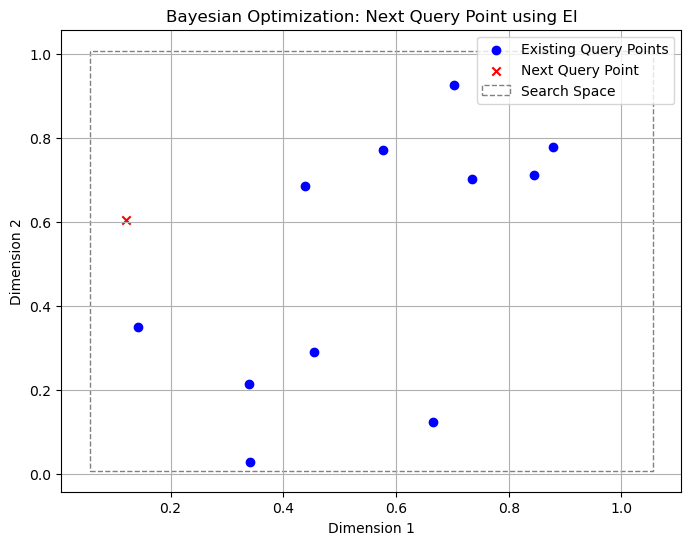

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize

# Step 1: Define the input and output data for function 2
X_train = np.array([[0.66579958, 0.12396913],
                    [0.87779099, 0.77862750],
                    [0.14269907, 0.34900513],
                    [0.84527543, 0.71112027],
                    [0.45464714, 0.29045518],
                    [0.57771284, 0.77197318],
                    [0.43816606, 0.68501826],
                    [0.34174959, 0.02869772],
                    [0.33864816, 0.21386725],
                    [0.70263656, 0.92656420],
                    [0.734909, 0.701711]]) 

y_train = np.array([1.32267704e-079, 1.03307824e-046, 7.71087511e-016,
                    3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
                    -2.08909327e-091, 2.53500115e-040, 3.60677119e-081,
                    6.22985647e-048, 0.5390316209844838])

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))  # Constant kernel * RBF kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)  #increase alpha to handle excess noise

# Step 3: Fit the GP model to the existing data
gp.fit(X_train, y_train)

# Step 4: Define the Expected Improvement (EI) acquisition function with exploration
def expected_improvement(x, model, X_train, y_train, xi=0.1):
    """
    Expected Improvement (EI) acquisition function with exploration.
    x: The point at which to evaluate the acquisition function
    model: The trained GaussianProcessRegressor model
    X_train: The previously evaluated points
    y_train: The previously observed values
    xi: Exploration-exploitation trade-off parameter (larger xi = more exploration)
    """
    # Reshape x to match expected input shape
    x = np.array(x).reshape(1, -1)
    
    # Predict the mean and standard deviation at the new point
    mu, sigma = model.predict(x, return_std=True)
    
    # Calculate the improvement over the current best value
    y_best = np.max(y_train)  # Maximization problem, so use the best so far (max of y_train)
    improvement = mu - y_best - xi  # Subtract xi for exploration
    
    # If sigma is small (i.e., uncertainty is low), we return no improvement
    ei = improvement * norm.cdf(improvement / sigma) + sigma * norm.pdf(improvement / sigma)
    
    return -ei  # We minimize, so negate the expected improvement

# Step 5: Optimize the acquisition function using scipy.optimize.minimize
def optimize_acquisition(model, X_train, y_train, length=0.5, xi=0.1):
    """
    Use scipy to optimize the acquisition function and return the next query point.
    In this version, the bounds are set based on a fixed length (radius) from the center of the observed points.
    """
    # Step 5a: Define the center of the search space (mean of X_train)
    center = np.mean(X_train, axis=0)  # Mean of the points in X_train (central point)
    
    # Step 5b: Set bounds based on the length (radius) around the center
    bounds = np.array([[center[0] - length, center[0] + length],  # Bounds for the first dimension
                       [center[1] - length, center[1] + length]])  # Bounds for the second dimension
    
    # Step 5c: Initial guess for optimization (random point within bounds)
    x0 = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(1, 2))
    
    # Step 5d: Optimize the acquisition function to find the next query point (mininising negates to maximise)
    result = minimize(expected_improvement, x0, args=(model, X_train, y_train, xi), bounds=bounds, method="L-BFGS-B")
    
    # Return the next query point
    return result.x

# Step 6: Find the next query point with higher exploration (xi=0.1)
next_point = optimize_acquisition(gp, X_train, y_train, length=0.5, xi=0.1)

# Step 7: Output the next query point in the required format (x, y) as 'x-y'
next_point_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}"
print(f"Next query point: {next_point_str}")

# Step 8: Plot the results
plt.figure(figsize=(8, 6))

# Plot the existing data points (X_train)
plt.scatter(X_train[:, 0], X_train[:, 1], color='blue', label='Existing Query Points')

# Plot the next query point
plt.scatter(next_point[0], next_point[1], color='red', marker='x', label='Next Query Point')

# Plot the search space (defined by the fixed length around the center)
center = np.mean(X_train, axis=0)  # Center of X_train
plt.gca().add_patch(plt.Rectangle((center[0] - 0.5, center[1] - 0.5), 1.0, 1.0, linewidth=1, edgecolor='gray', facecolor='none', linestyle='--', label='Search Space'))

# Labels and legend
plt.title("Bayesian Optimization: Next Query Point using EI")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

#### Using UCB acquisition

Next query point: 0.721682-0.396301


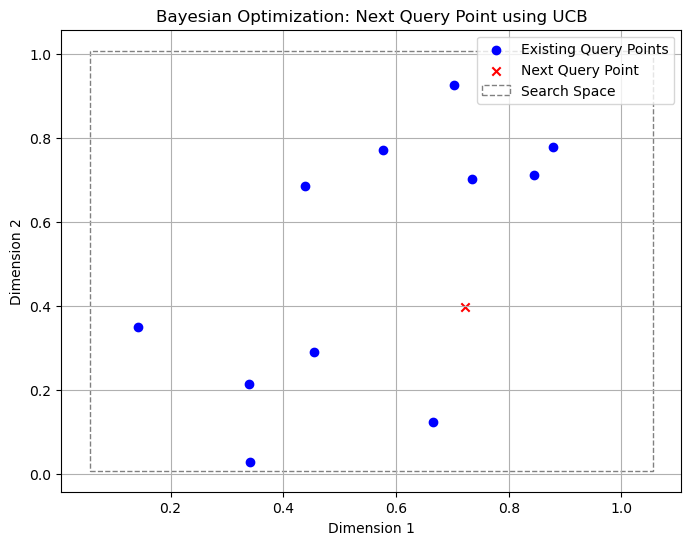

In [20]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Step 1: Define the input and output data for function 2 
X_train = np.array([[0.66579958, 0.12396913],
                    [0.87779099, 0.77862750],
                    [0.14269907, 0.34900513],
                    [0.84527543, 0.71112027],
                    [0.45464714, 0.29045518],
                    [0.57771284, 0.77197318],
                    [0.43816606, 0.68501826],
                    [0.34174959, 0.02869772],
                    [0.33864816, 0.21386725],
                    [0.70263656, 0.92656420],
                    [0.734909, 0.701711]]) 

y_train = np.array([1.32267704e-079, 1.03307824e-046, 7.71087511e-016,
                    3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
                    -2.08909327e-091, 2.53500115e-040, 3.60677119e-081,
                    6.22985647e-048, 0.5390316209844838])

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))  # Constant kernel * RBF kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)  #increase alpha to handle excess noise

# Step 3: Fit the GP model to the existing data
gp.fit(X_train, y_train)

# Step 4: Define the Upper Confidence Bound (UCB) acquisition function
def ucb(x, model, kappa=2.5):
    """
    Upper Confidence Bound (UCB) acquisition function.
    x: The point at which to evaluate the acquisition function
    model: The trained GaussianProcessRegressor model
    kappa: Exploration-exploitation trade-off parameter
    """
    # Reshape x to match expected input shape
    x = np.array(x).reshape(1, -1)
    
    # Predict the mean and standard deviation at the new point
    mu, sigma = model.predict(x, return_std=True)
    
    # UCB acquisition function: mu + kappa * sigma
    return -(mu + kappa * sigma)  # We minimize, so negate the UCB value

# Step 5: Optimize the acquisition function using scipy.optimize.minimize
def optimize_acquisition(model, X_train, kappa=2.5):
    """
    Use scipy to optimize the acquisition function and return the next query point.
    """
    # Define bounds for the search space (adjust as necessary)
    bounds = np.array([[0.0, 1.0], [0.0, 1.0]])  # Example bounds, adjust as per the problem
    
    # Initial guess for the optimization
    x0 = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(1, 2))
    
    # Optimize the acquisition function
    result = minimize(ucb, x0, args=(model, kappa), bounds=bounds, method="L-BFGS-B")
    
    # Return the next point to sample
    return result.x

# Step 6: Find the next query point
next_point = optimize_acquisition(gp, X_train)

# Step 7: Output the next query point in the required format (x, y) as 'x-y'
next_point_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}"
print(f"Next query point: {next_point_str}")

# Step 8: Plot the results
plt.figure(figsize=(8, 6))

# Plot the existing data points (X_train)
plt.scatter(X_train[:, 0], X_train[:, 1], color='blue', label='Existing Query Points')

# Plot the next query point
plt.scatter(next_point[0], next_point[1], color='red', marker='x', label='Next Query Point')

# Plot the search space (defined by the fixed length around the center)
center = np.mean(X_train, axis=0)  # Center of X_train
plt.gca().add_patch(plt.Rectangle((center[0] - 0.5, center[1] - 0.5), 1.0, 1.0, linewidth=1, edgecolor='gray', facecolor='none', linestyle='--', label='Search Space'))

# Labels and legend
plt.title("Bayesian Optimization: Next Query Point using UCB")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()

# Show the plot
plt.grid(True)
plt.show() 

### Function 3

#### Using EI acquisition

Next query point: 0.696842-0.720902-0.508242


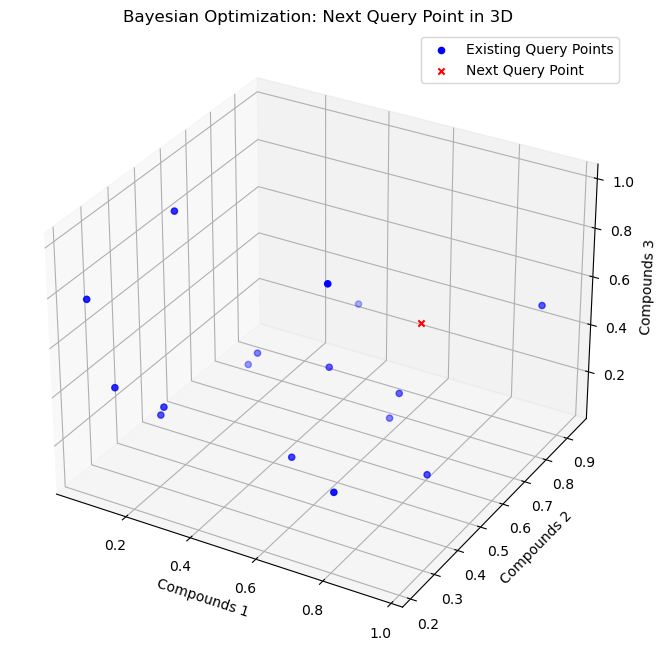

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize

# Step 1: Define the input and output data for function 3 (drug discovery)
X_train = np.array([[0.17152521, 0.34391687, 0.24873720],
                    [0.24211446, 0.64407427, 0.27243281],
                    [0.53490572, 0.39850092, 0.17338873],
                    [0.49258141, 0.61159319, 0.34017639],
                    [0.13462167, 0.21991724, 0.45820622],
                    [0.34552327, 0.94135983, 0.26936348],
                    [0.15183663, 0.43999062, 0.99088187],
                    [0.64550284, 0.39714294, 0.91977134],
                    [0.74691195, 0.28419631, 0.22629985],
                    [0.17047699, 0.69703240, 0.14916943],
                    [0.22054934, 0.29782524, 0.34355534],
                    [0.66601366, 0.67198515, 0.24629530],
                    [0.04680895, 0.23136024, 0.77061759],
                    [0.60009728, 0.72513573, 0.06608864],
                    [0.96599485, 0.86111969, 0.56682913],
                    [0.836816, 0.551524, 0.084734]]) #New 3D numpy array input query point


y_train = np.array([-0.1121222 , -0.08796286, -0.11141465, -0.03483531, -0.04800758,
                    -0.11062091, -0.39892551, -0.11386851, -0.13146061, -0.09418956,
                    -0.04694741, -0.10596504, -0.11804826, -0.03637783, -0.05675837, 
                    -0.03172685348164523]) #New 1D numpy array output

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-3, 1e2))  # Constant kernel * RBF kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)

# Step 3: Fit the GP model to the existing data
gp.fit(X_train, y_train)

# Step 4: Define the Expected Improvement (EI) acquisition function with exploration
def expected_improvement(x, model, X_train, y_train, xi=0.1):
    """
    Expected Improvement (EI) acquisition function with exploration.
    x: The point at which to evaluate the acquisition function
    model: The trained GaussianProcessRegressor model
    X_train: The previously evaluated points
    y_train: The previously observed values
    xi: Exploration-exploitation trade-off parameter (larger xi = more exploration)
    """
    # Reshape x to match expected input shape
    x = np.array(x).reshape(1, -1)
    
    # Predict the mean and standard deviation at the new point
    mu, sigma = model.predict(x, return_std=True)
    
    # Calculate the improvement over the current best value
    y_best = np.max(y_train)  # Maximization problem, so use the best so far (max of y_train)
    improvement = mu - y_best - xi  # Subtract xi for exploration
    
    # If sigma is small (i.e., uncertainty is low), we return no improvement
    ei = improvement * norm.cdf(improvement / sigma) + sigma * norm.pdf(improvement / sigma)
    
    return -ei  # We minimize, so negate the expected improvement

# Step 5: Optimize the acquisition function using scipy.optimize.minimize
def optimize_acquisition(model, X_train, y_train, length=0.5, xi=0.1):
    """
    Use scipy to optimize the acquisition function and return the next query point.
    In this version, the bounds are set based on a fixed length (radius) from the center of the observed points.
    """
    # Step 5a: Define the center of the search space (mean of X_train)
    center = np.mean(X_train, axis=0)  # Mean of the points in X_train (central point)
    
    # Step 5b: Set bounds based on the length (radius) around the center
    bounds = np.array([[center[0] - length, center[0] + length],  # Bounds for the first dimension
                       [center[1] - length, center[1] + length],  # Bounds for the second dimension
                       [center[2] - length, center[2] + length]])  # Bounds for the third dimension
    
    # Step 5c: Initial guess for optimization (random point within bounds)
    x0 = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(1, 3))
    
    # Step 5d: Optimize the acquisition function to find the next query point
    result = minimize(expected_improvement, x0, args=(model, X_train, y_train, xi), bounds=bounds, method="L-BFGS-B")
    
    # Return the next query point
    return result.x

# Step 6: Find the next query point with higher exploration (xi=0.1)
next_point = optimize_acquisition(gp, X_train, y_train, length=0.5, xi=0.1)

# Step 7: Output the next query point in the required format (x, y, z) as 'x-y-z'
next_point_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}"
print(f"Next query point: {next_point_str}")

# Step 8: Plot the results (in 3D)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the existing data points (X_train)
ax.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c='blue', label='Existing Query Points')

# Plot the next query point
ax.scatter(next_point[0], next_point[1], next_point[2], c='red', marker='x', label='Next Query Point')

# Labels and legend
ax.set_title("Bayesian Optimization: Next Query Point in 3D")
ax.set_xlabel("Compounds 1")
ax.set_ylabel("Compounds 2")
ax.set_zlabel("Compounds 3")
ax.legend()

# Show the plot
plt.show()

#### Using UCB acquisition

Next query point: 0.935768-0.019792-0.882909


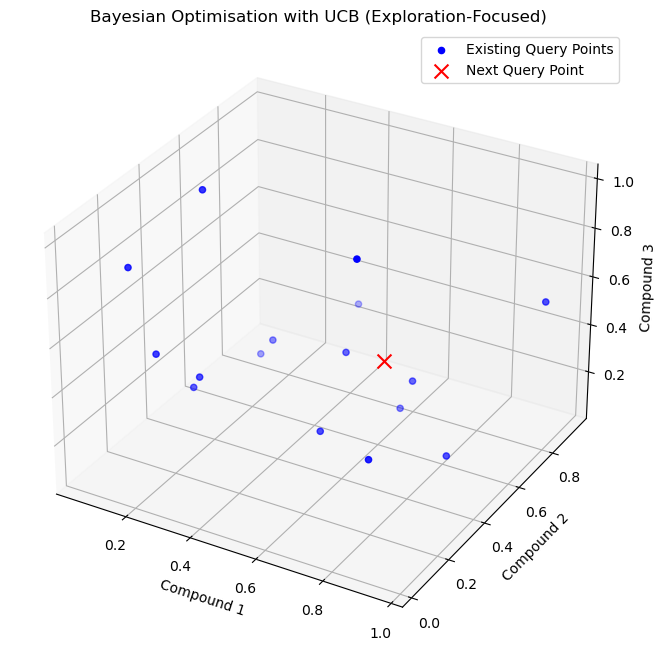

In [213]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize

# Step 1: Define the input and output data for function 3 (drug discovery)
X_train = np.array([[0.17152521, 0.34391687, 0.24873720],
                    [0.24211446, 0.64407427, 0.27243281],
                    [0.53490572, 0.39850092, 0.17338873],
                    [0.49258141, 0.61159319, 0.34017639],
                    [0.13462167, 0.21991724, 0.45820622],
                    [0.34552327, 0.94135983, 0.26936348],
                    [0.15183663, 0.43999062, 0.99088187],
                    [0.64550284, 0.39714294, 0.91977134],
                    [0.74691195, 0.28419631, 0.22629985],
                    [0.17047699, 0.69703240, 0.14916943],
                    [0.22054934, 0.29782524, 0.34355534],
                    [0.66601366, 0.67198515, 0.24629530],
                    [0.04680895, 0.23136024, 0.77061759],
                    [0.60009728, 0.72513573, 0.06608864],
                    [0.96599485, 0.86111969, 0.56682913],
                    [0.83681600, 0.55152400, 0.08473400]])

y_train = np.array([-0.11212220, -0.08796286, -0.11141465, -0.03483531, -0.04800758,
                    -0.11062091, -0.39892551, -0.11386851, -0.13146061, -0.09418956,
                    -0.04694741, -0.10596504, -0.11804826, -0.03637783, -0.05675837,
                    -0.03172685348164523])

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-3, 1e2))
gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    alpha=1e-2   # noise-aware (important for week 2 & higher dimensions)
)

# Step 3: Fit the GP model
gp.fit(X_train, y_train)

# Step 4: Define the Upper Confidence Bound (UCB) acquisition function
def ucb(x, model, kappa=2.5):
    """
    Upper Confidence Bound (UCB) acquisition function.
    kappa controls exploration (higher = more exploration).
    """
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return -(mu + kappa * sigma)  # negate because we minimize

# Step 5: Optimize the acquisition function
def optimize_acquisition(model, X_train, length=0.5, kappa=2.5):
    """
    Optimize UCB within a bounded region centred on existing samples.
    """
    center = np.mean(X_train, axis=0)

    bounds = np.array([
        [center[0] - length, center[0] + length],
        [center[1] - length, center[1] + length],
        [center[2] - length, center[2] + length]
    ])

    x0 = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(1, 3))

    result = minimize(
        ucb,
        x0,
        args=(model, kappa),
        bounds=bounds,
        method="L-BFGS-B"
    )

    return result.x

# Step 6: Find the next query point (exploration-focused)
next_point = optimize_acquisition(gp, X_train, length=0.5, kappa=2.5)

# Step 7: Output next query point
next_point_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}"
print(f"Next query point: {next_point_str}")

# Step 8: Plot the results (3D)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2],
           c='blue', label='Existing Query Points')

ax.scatter(next_point[0], next_point[1], next_point[2],
           c='red', marker='x', s=100, label='Next Query Point')

ax.set_title("Bayesian Optimisation with UCB (Exploration-Focused)")
ax.set_xlabel("Compound 1")
ax.set_ylabel("Compound 2")
ax.set_zlabel("Compound 3")
ax.legend()

plt.show()

### Function 4

#### Using EI acquisition 

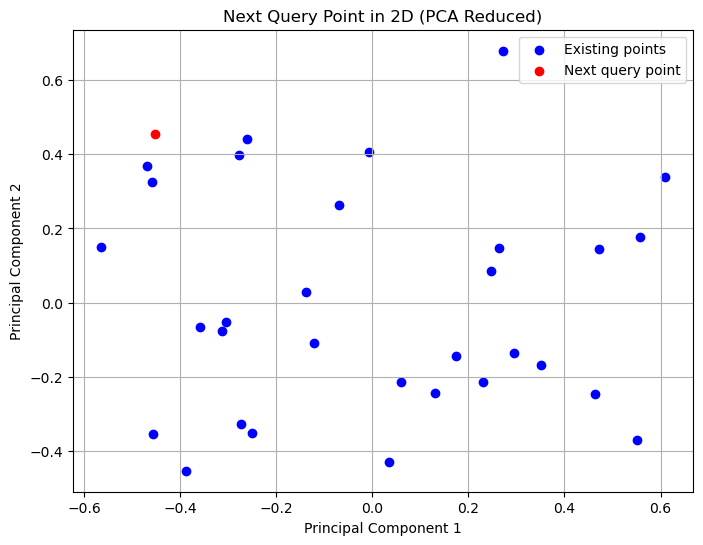

Next query point in 4D: [0.01367026 0.33276383 0.12597792 0.38293339]


In [101]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.decomposition import PCA

# Step 1: Define the input and output data for function 4 (warehouse optimization)
X_train = np.array([[0.89698105, 0.72562797, 0.17540431, 0.70169437],
                    [0.88935640, 0.49958786, 0.53926886, 0.50878344],
                    [0.25094624, 0.03369313, 0.14538002, 0.49493242],
                    [0.34696206, 0.00625040, 0.76056361, 0.61302356],
                    [0.12487118, 0.12977019, 0.38440048, 0.28707610],
                    [0.80130271, 0.50023109, 0.70664456, 0.19510284],
                    [0.24770826, 0.06044543, 0.04218635, 0.44132425],
                    [0.74670224, 0.75709150, 0.36935306, 0.20656628],
                    [0.40066503, 0.07257425, 0.88676825, 0.24384229],
                    [0.62607060, 0.58675126, 0.43880578, 0.77885769],
                    [0.95713529, 0.59764438, 0.76611385, 0.77620991],
                    [0.73281243, 0.14524998, 0.47681272, 0.13336573],
                    [0.65511548, 0.07239183, 0.68715175, 0.08151656],
                    [0.21973443, 0.83203134, 0.48286416, 0.08256923],
                    [0.48859419, 0.21196510, 0.93917791, 0.37619173],
                    [0.16713049, 0.87655456, 0.21723954, 0.95980098],
                    [0.21691119, 0.16608583, 0.24137226, 0.77006248],
                    [0.38748784, 0.80453226, 0.75179548, 0.72382744],
                    [0.98562189, 0.66693268, 0.15678328, 0.85653480],
                    [0.03782483, 0.66485335, 0.16198218, 0.25392378],
                    [0.68348638, 0.90277010, 0.33541983, 0.99948256],
                    [0.17034731, 0.75695908, 0.27652049, 0.53123150],
                    [0.85965692, 0.91959232, 0.20613873, 0.09779683],
                    [0.28213837, 0.50598691, 0.53053084, 0.09630162],
                    [0.32607578, 0.47236690, 0.453192  , 0.10588734],
                    [0.94838936, 0.89451301, 0.85163782, 0.55219629],
                    [0.66495539, 0.04656628, 0.11677747, 0.79371778],
                    [0.57776561, 0.42877174, 0.42582587, 0.24900741],
                    [0.73861301, 0.48210263, 0.70936644, 0.50397001],
                    [0.85481080, 0.49396462, 0.73530997, 0.80809201],
                    [0.919144, 0.533196, 0.169848, 0.070054]])


y_train = np.array([-22.10828779, -14.60139663, -11.69993246, -16.05376511,
                    -10.06963343, -15.48708254, -12.68168498, -16.02639977,
                    -17.04923465, -12.74176599, -27.31639636, -13.52764887,
                    -16.6791152 , -16.50715856, -17.81799934, -26.56182083,
                    -12.75832422, -19.44155762, -28.90327367, -13.70274694,
                    -29.4270914 , -11.56574199, -26.85778644, -7.96677535,
                    -6.70208925, -32.62566022, -19.98949793, -4.02554228,
                    -13.12278233, -23.1394284, -19.975065657531825])

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))  # Constant kernel * RBF kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)

# Step 3: Fit the GP model to the existing data
gp.fit(X_train, y_train)

# Step 4: Define the Expected Improvement (EI) acquisition function with exploration
def expected_improvement(x, model, X_train, y_train, xi=0.1):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    y_best = np.max(y_train)  # Maximization problem
    improvement = mu - y_best - xi  # Subtract xi for exploration
    ei = improvement * norm.cdf(improvement / sigma) + sigma * norm.pdf(improvement / sigma)
    return -ei  # Minimize the acquisition function (negate to maximise)

# Step 5: Optimize the acquisition function to find the next query point
def optimize_acquisition(model, X_train, y_train, length=0.5, xi=0.1):
    # Random starting point for optimization
    x0 = np.random.uniform(0, 1, size=(1, 4))
    
    # Optimize the acquisition function
    res = minimize(expected_improvement, x0, args=(model, X_train, y_train, xi),
                   bounds=[(0, 1), (0, 1), (0, 1), (0, 1)])
    
    # Get the new query point
    new_x = res.x
    return new_x

# Step 6: Find the next query point
next_query_point = optimize_acquisition(gp, X_train, y_train)

# Step 7: Visualize the next query point in 2D using PCA (since we have 4D data)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)  # Reduce dimensionality to 2D

# Step 8: Plot the existing points and the next query point
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], color='blue', label='Existing points')
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))  # Transform the next query point to 2D
plt.scatter(next_query_point_pca[:, 0], next_query_point_pca[:, 1], color='red', label='Next query point')

plt.title('Next Query Point in 2D (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Print the next query point in 4D
print("Next query point in 4D:", next_query_point)

#### Using UCB acquisition

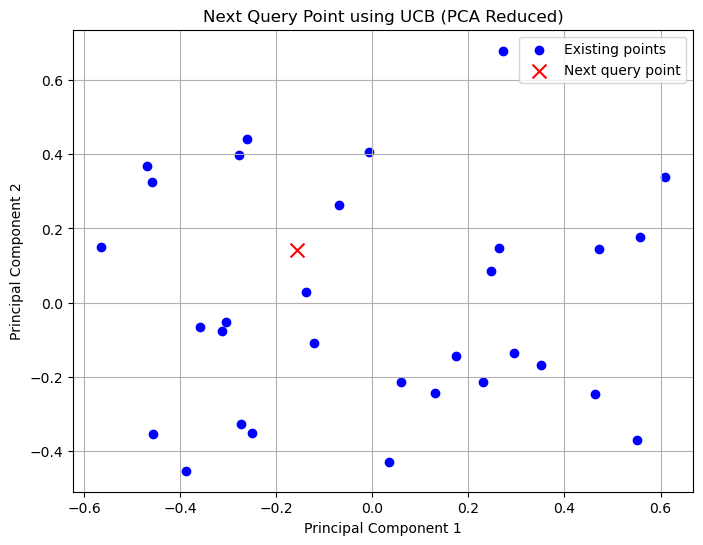

Next query point in 4D: [0.41182732 0.39209982 0.31715934 0.43042939]


In [117]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.decomposition import PCA

# Step 1: Define the input and output data for function 4 (warehouse optimization)
X_train = np.array([[0.89698105, 0.72562797, 0.17540431, 0.70169437],
                    [0.88935640, 0.49958786, 0.53926886, 0.50878344],
                    [0.25094624, 0.03369313, 0.14538002, 0.49493242],
                    [0.34696206, 0.00625040, 0.76056361, 0.61302356],
                    [0.12487118, 0.12977019, 0.38440048, 0.28707610],
                    [0.80130271, 0.50023109, 0.70664456, 0.19510284],
                    [0.24770826, 0.06044543, 0.04218635, 0.44132425],
                    [0.74670224, 0.75709150, 0.36935306, 0.20656628],
                    [0.40066503, 0.07257425, 0.88676825, 0.24384229],
                    [0.62607060, 0.58675126, 0.43880578, 0.77885769],
                    [0.95713529, 0.59764438, 0.76611385, 0.77620991],
                    [0.73281243, 0.14524998, 0.47681272, 0.13336573],
                    [0.65511548, 0.07239183, 0.68715175, 0.08151656],
                    [0.21973443, 0.83203134, 0.48286416, 0.08256923],
                    [0.48859419, 0.21196510, 0.93917791, 0.37619173],
                    [0.16713049, 0.87655456, 0.21723954, 0.95980098],
                    [0.21691119, 0.16608583, 0.24137226, 0.77006248],
                    [0.38748784, 0.80453226, 0.75179548, 0.72382744],
                    [0.98562189, 0.66693268, 0.15678328, 0.85653480],
                    [0.03782483, 0.66485335, 0.16198218, 0.25392378],
                    [0.68348638, 0.90277010, 0.33541983, 0.99948256],
                    [0.17034731, 0.75695908, 0.27652049, 0.53123150],
                    [0.85965692, 0.91959232, 0.20613873, 0.09779683],
                    [0.28213837, 0.50598691, 0.53053084, 0.09630162],
                    [0.32607578, 0.47236690, 0.45319200, 0.10588734],
                    [0.94838936, 0.89451301, 0.85163782, 0.55219629],
                    [0.66495539, 0.04656628, 0.11677747, 0.79371778],
                    [0.57776561, 0.42877174, 0.42582587, 0.24900741],
                    [0.73861301, 0.48210263, 0.70936644, 0.50397001],
                    [0.85481080, 0.49396462, 0.73530997, 0.80809201],
                    [0.91914400, 0.53319600, 0.16984800, 0.07005400]])

y_train = np.array([-22.10828779, -14.60139663, -11.69993246, -16.05376511,
                    -10.06963343, -15.48708254, -12.68168498, -16.02639977,
                    -17.04923465, -12.74176599, -27.31639636, -13.52764887,
                    -16.67911520, -16.50715856, -17.81799934, -26.56182083,
                    -12.75832422, -19.44155762, -28.90327367, -13.70274694,
                    -29.42709140, -11.56574199, -26.85778644, -7.96677535,
                    -6.70208925, -32.62566022, -19.98949793, -4.02554228,
                    -13.12278233, -23.13942840, -19.975065657531825])

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    alpha=1e-2   # noise-aware, exploration-friendly
)

# Step 3: Fit the GP model
gp.fit(X_train, y_train)

# Step 4: Define the Upper Confidence Bound (UCB) acquisition function
def ucb(x, model, kappa=2.5):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return -(mu + kappa * sigma)  # negate because we minimise

# Step 5: Optimize the acquisition function
def optimize_acquisition(model, kappa=2.5):
    x0 = np.random.uniform(0, 1, size=(1, 4))

    res = minimize(
        ucb,
        x0,
        args=(model, kappa),
        bounds=[(0, 1), (0, 1), (0, 1), (0, 1)],
        method="L-BFGS-B"
    )

    return res.x

# Step 6: Find the next query point
next_query_point = optimize_acquisition(gp, kappa=2.5)

# Step 7: Visualize the next query point in 2D using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))

# Step 8: Plot
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
            color='blue', label='Existing points')
plt.scatter(next_query_point_pca[:, 0], next_query_point_pca[:, 1],
            color='red', marker='x', s=100, label='Next query point')

plt.title('Next Query Point using UCB (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Print the next query point in 4D
print("Next query point in 4D:", next_query_point)

### Function 5

#### Using EI acquisition

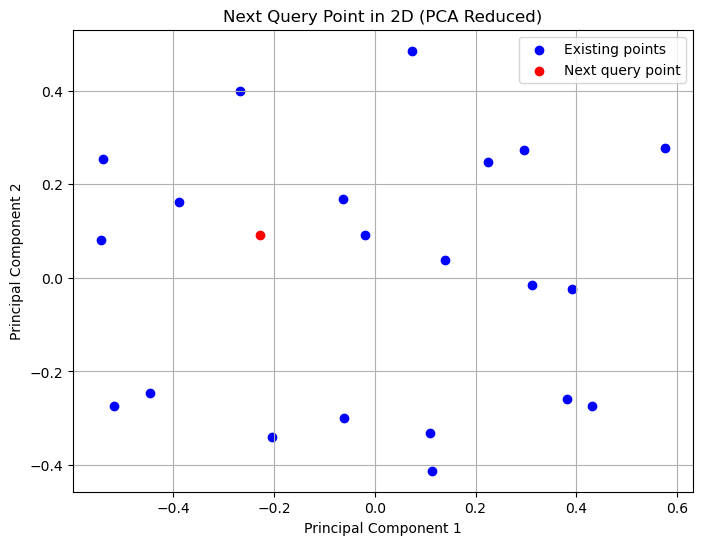

Next query point in 4D: [0.72433356 0.75526735 0.14212099 0.47449239]


In [214]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.decomposition import PCA

# Step 1: Define the input and output data for function 5 (chemical process optimization)
X_train = np.array([[0.19144708, 0.03819337, 0.60741781, 0.41458414],
                    [0.75865295, 0.53651774, 0.65600038, 0.36034155],
                    [0.43834987, 0.80433970, 0.21024527, 0.15129482],
                    [0.70605083, 0.53419196, 0.26424335, 0.48208755],
                    [0.83647799, 0.19360965, 0.66389270, 0.78564888],
                    [0.68343225, 0.11866264, 0.82904591, 0.56757661],
                    [0.55362148, 0.66734998, 0.32380582, 0.81486975],
                    [0.35235627, 0.32224153, 0.11697937, 0.47311252],
                    [0.15378571, 0.72938169, 0.42259844, 0.44307417],
                    [0.46344227, 0.63002451, 0.10790646, 0.95764390],
                    [0.67749115, 0.35850951, 0.47959222, 0.07288048],
                    [0.58397341, 0.14724265, 0.34809746, 0.42861465],
                    [0.30688872, 0.31687813, 0.62263448, 0.09539906],
                    [0.51114177, 0.81795700, 0.72871042, 0.11235362],
                    [0.43893338, 0.77409176, 0.37816709, 0.93369621],
                    [0.22418902, 0.84648049, 0.87948418, 0.87851568],
                    [0.72526172, 0.47987049, 0.08894684, 0.75976022],
                    [0.35548161, 0.63961937, 0.41761768, 0.12260384],
                    [0.11987923, 0.86254031, 0.64333133, 0.84980383],
                    [0.12688467, 0.15342962, 0.77016219, 0.19051811],
                    [0.812122, 0.009812, 0.681024, 0.238036]]) 


y_train = np.array([6.44434399e+01, 1.83013796e+01, 1.12939795e-01, 4.21089813e+00, 
                    2.58370525e+02, 7.84343889e+01, 5.75715369e+01, 1.09571876e+02,
                    8.84799176e+00, 2.33223610e+02, 2.44230883e+01, 6.44201468e+01,
                    6.34767158e+01, 7.97291299e+01, 3.55806818e+02, 1.08885962e+03,
                    2.88667516e+01, 4.51815703e+01, 4.31612757e+02, 9.97233189e+00,
                    24.76799409895627])

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))  # Constant kernel * RBF kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)

# Step 3: Fit the GP model to the existing data
gp.fit(X_train, y_train)

# Step 4: Define the Expected Improvement (EI) acquisition function with exploration
def expected_improvement(x, model, X_train, y_train, xi=0.1):
    """
    Expected Improvement (EI) acquisition function with exploration.
    x: The point at which to evaluate the acquisition function
    model: The trained GaussianProcessRegressor model
    X_train: The previously evaluated points
    y_train: The previously observed values
    xi: Exploration-exploitation trade-off parameter (larger xi = more exploration)
    """
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    y_best = np.max(y_train)  # Maximization problem
    improvement = mu - y_best - xi  # Subtract xi for exploration
    ei = improvement * norm.cdf(improvement / sigma) + sigma * norm.pdf(improvement / sigma)
    return -ei  # Minimize the acquisition function

# Step 5: Optimize the acquisition function to find the next query point
def optimize_acquisition(model, X_train, y_train, length=0.5, xi=0.1):
    # Random starting point for optimization
    x0 = np.random.uniform(0, 1, size=(1, 4))
    
    # Optimize the acquisition function
    res = minimize(expected_improvement, x0, args=(model, X_train, y_train, xi),
                   bounds=[(0, 1), (0, 1), (0, 1), (0, 1)])
    
    # Get the new query point
    new_x = res.x
    return new_x

# Step 6: Find the next query point
next_query_point = optimize_acquisition(gp, X_train, y_train)

# Step 7: Visualize the next query point in 2D using PCA (since we have 4D data)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)  # Reduce dimensionality to 2D

# Step 8: Plot the existing points and the next query point
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], color='blue', label='Existing points')
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))  # Transform the next query point to 2D
plt.scatter(next_query_point_pca[:, 0], next_query_point_pca[:, 1], color='red', label='Next query point')

plt.title('Next Query Point in 2D (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Print the next query point in 4D
print("Next query point in 4D:", next_query_point)

#### Using UCB acquisition

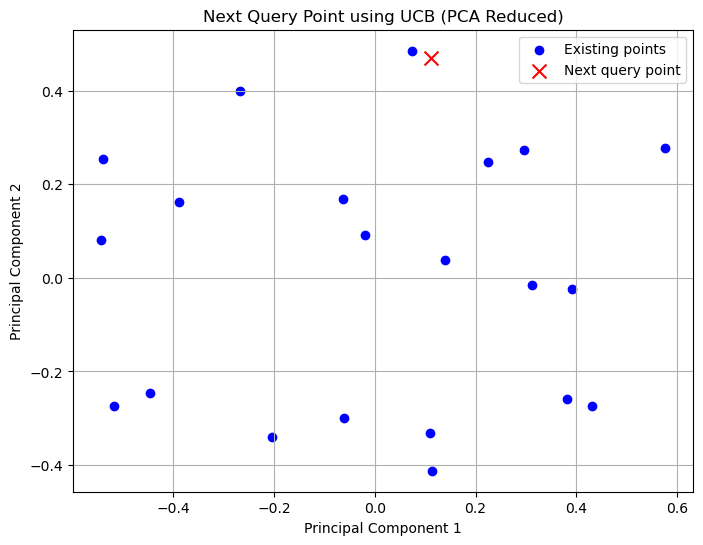

Next query point in 4D: [0.8235304  0.17369191 0.63651394 0.7373068 ]


In [222]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.decomposition import PCA

# Step 1: Define the input and output data for function 5 (chemical process optimization)
X_train = np.array([[0.19144708, 0.03819337, 0.60741781, 0.41458414],
                    [0.75865295, 0.53651774, 0.65600038, 0.36034155],
                    [0.43834987, 0.80433970, 0.21024527, 0.15129482],
                    [0.70605083, 0.53419196, 0.26424335, 0.48208755],
                    [0.83647799, 0.19360965, 0.66389270, 0.78564888],
                    [0.68343225, 0.11866264, 0.82904591, 0.56757661],
                    [0.55362148, 0.66734998, 0.32380582, 0.81486975],
                    [0.35235627, 0.32224153, 0.11697937, 0.47311252],
                    [0.15378571, 0.72938169, 0.42259844, 0.44307417],
                    [0.46344227, 0.63002451, 0.10790646, 0.95764390],
                    [0.67749115, 0.35850951, 0.47959222, 0.07288048],
                    [0.58397341, 0.14724265, 0.34809746, 0.42861465],
                    [0.30688872, 0.31687813, 0.62263448, 0.09539906],
                    [0.51114177, 0.81795700, 0.72871042, 0.11235362],
                    [0.43893338, 0.77409176, 0.37816709, 0.93369621],
                    [0.22418902, 0.84648049, 0.87948418, 0.87851568],
                    [0.72526172, 0.47987049, 0.08894684, 0.75976022],
                    [0.35548161, 0.63961937, 0.41761768, 0.12260384],
                    [0.11987923, 0.86254031, 0.64333133, 0.84980383],
                    [0.12688467, 0.15342962, 0.77016219, 0.19051811],
                    [0.81212200, 0.00981200, 0.68102400, 0.23803600]])

y_train = np.array([6.44434399e+01, 1.83013796e+01, 1.12939795e-01, 4.21089813e+00, 
                    2.58370525e+02, 7.84343889e+01, 5.75715369e+01, 1.09571876e+02,
                    8.84799176e+00, 2.33223610e+02, 2.44230883e+01, 6.44201468e+01,
                    6.34767158e+01, 7.97291299e+01, 3.55806818e+02, 1.08885962e+03,
                    2.88667516e+01, 4.51815703e+01, 4.31612757e+02, 9.97233189e+00,
                    24.76799409895627])

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel,
                             n_restarts_optimizer=10,
                             alpha=1e-2)

# Step 3: Fit the GP model
gp.fit(X_train, y_train)

# Step 4: Define the Upper Confidence Bound (UCB) acquisition function
def ucb(x, model, kappa=2.5):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return -(mu + kappa * sigma)  # negate for minimisation

# Step 5: Optimize the acquisition function
def optimize_acquisition(model, kappa=2.5):
    x0 = np.random.uniform(0, 1, size=(1, 4))

    res = minimize(ucb,
                   x0,
                   args=(model, kappa),
                   bounds=[(0, 1), (0, 1), (0, 1), (0, 1)],
                   method="L-BFGS-B")

    return res.x

# Step 6: Find the next query point
next_query_point = optimize_acquisition(gp, kappa=2.5)

# Step 7: Visualize the next query point in 2D using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))

# Step 8: Plot
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
            color='blue', label='Existing points')
plt.scatter(next_query_point_pca[:, 0], next_query_point_pca[:, 1],
            color='red', marker='x', s=100, label='Next query point')

plt.title('Next Query Point using UCB (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Print the next query point in 4D
print("Next query point in 4D:", next_query_point)

### Function 6

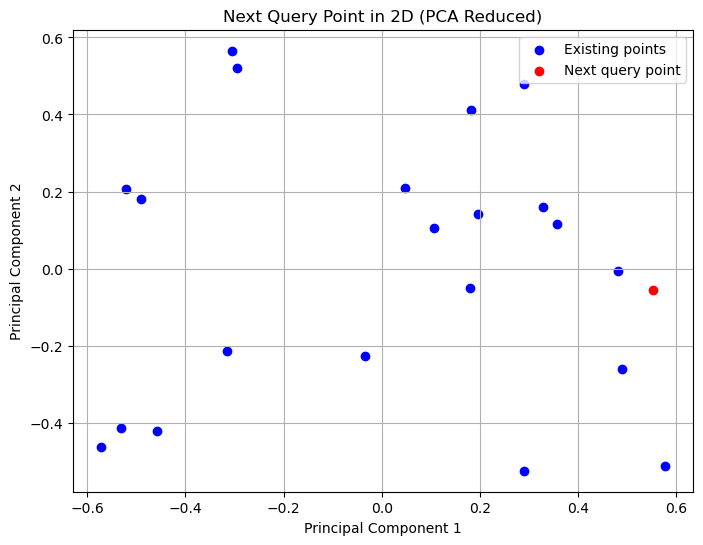

Next query point in 5D: [0.43819995 0.86358878 0.62937387 0.0225984  0.76259351]


In [225]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.decomposition import PCA

# Step 1: Define the input and output data for function 6 (cake recipe optimization)
X_train = np.array([[0.7281861 , 0.15469257, 0.73255167, 0.69399651, 0.05640131],
                    [0.24238435, 0.84409997, 0.57780910, 0.67902128, 0.50195289],
                    [0.72952261, 0.74810620, 0.67977464, 0.35655228, 0.67105368],
                    [0.77062024, 0.11440374, 0.04677993, 0.64832428, 0.27354905],
                    [0.61881230, 0.33180214, 0.18728787, 0.75623847, 0.32883480],
                    [0.78495809, 0.91068235, 0.70812010, 0.95922543, 0.00491150],
                    [0.14511079, 0.89668460, 0.89632223, 0.72627154, 0.23627199],
                    [0.94506907, 0.28845905, 0.97880576, 0.96165559, 0.59801594],
                    [0.12572016, 0.86272469, 0.02854433, 0.24660527, 0.75120624],
                    [0.75759436, 0.35583141, 0.01652290, 0.43420720, 0.11243304],
                    [0.53679690, 0.30878091, 0.41187929, 0.38822518, 0.52252830],
                    [0.95773967, 0.23566857, 0.09914585, 0.15680593, 0.07131737],
                    [0.62930790, 0.80348368, 0.81140844, 0.04561319, 0.11062446],
                    [0.02173531, 0.42808424, 0.83593944, 0.48948866, 0.51108173],
                    [0.43934426, 0.69892383, 0.42682022, 0.10947609, 0.87788847],
                    [0.25890557, 0.79367771, 0.64211390, 0.19667346, 0.59310318],
                    [0.43216593, 0.71561781, 0.34181910, 0.70499988, 0.61496184],
                    [0.78287982, 0.53633586, 0.44328356, 0.85969983, 0.01032599],
                    [0.92177620, 0.93187122, 0.41487637, 0.59505727, 0.73562569],
                    [0.12667892, 0.29147030, 0.06452848, 0.68051460, 0.89281919],
                    [0.864822, 0.772164, 0.803941, 0.780551, 0.909036]])


y_train = np.array([-0.71426495, -1.20995524, -1.67219994, -1.53605771, -0.82923655,
                    -1.24704893, -1.23378638, -1.69434344, -2.57116963, -1.30911635,
                    -1.14478485, -1.91267714, -1.62283895, -1.35668211, -2.01842540,
                    -1.70255784, -1.29424696, -0.93575656, -2.15576776, -1.74688209,
                    -1.8405636029585657])

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))  # Constant kernel * RBF kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)

# Step 3: Fit the GP model to the existing data
gp.fit(X_train, y_train)

# Step 4: Define the Expected Improvement (EI) acquisition function with exploration
def expected_improvement(x, model, X_train, y_train, xi=0.1):
    """
    Expected Improvement (EI) acquisition function with exploration.
    x: The point at which to evaluate the acquisition function
    model: The trained GaussianProcessRegressor model
    X_train: The previously evaluated points
    y_train: The previously observed values
    xi: Exploration-exploitation trade-off parameter (larger xi = more exploration)
    """
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    y_best = np.max(y_train)  # Maximization problem
    improvement = mu - y_best - xi  # Subtract xi for exploration
    ei = improvement * norm.cdf(improvement / sigma) + sigma * norm.pdf(improvement / sigma)
    return -ei  # Minimize the acquisition function

# Step 5: Optimize the acquisition function to find the next query point
def optimize_acquisition(model, X_train, y_train, length=0.5, xi=0.1):
    # Random starting point for optimization
    x0 = np.random.uniform(0, 1, size=(1, 5))
    
    # Optimize the acquisition function
    res = minimize(expected_improvement, x0, args=(model, X_train, y_train, xi),
                   bounds=[(0, 1), (0, 1), (0, 1), (0, 1), (0, 1)])
    
    # Get the new query point
    new_x = res.x
    return new_x

# Step 6: Find the next query point
next_query_point = optimize_acquisition(gp, X_train, y_train)

# Step 7: Visualize the next query point in 2D using PCA (since we have 5D data)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)  # Reduce dimensionality to 2D

# Step 8: Plot the existing points and the next query point
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], color='blue', label='Existing points')
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))  # Transform the next query point to 2D
plt.scatter(next_query_point_pca[:, 0], next_query_point_pca[:, 1], color='red', label='Next query point')

plt.title('Next Query Point in 2D (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Print the next query point in 5D
print("Next query point in 5D:", next_query_point)

#### Using UCB acquisition

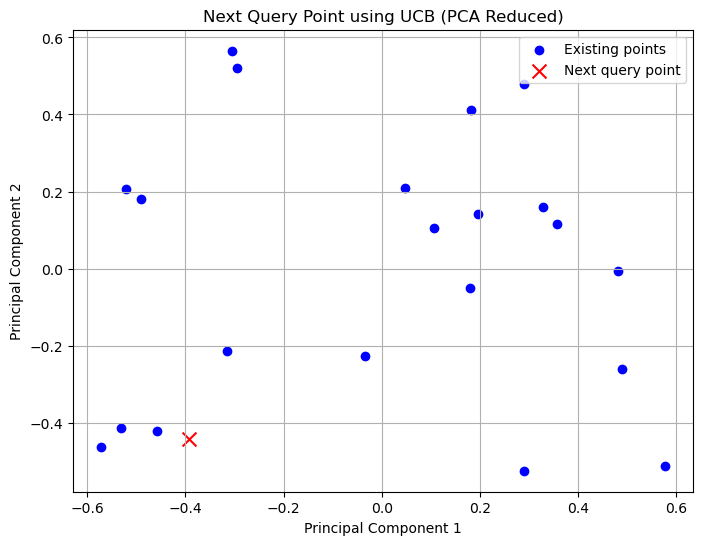

Next query point in 5D: [0. 0. 0. 1. 0.]


In [368]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler 

# Step 1: Define the input and output data for function 6 (cake recipe optimization)
X_train = np.array([[0.7281861 , 0.15469257, 0.73255167, 0.69399651, 0.05640131],
                    [0.24238435, 0.84409997, 0.57780910, 0.67902128, 0.50195289],
                    [0.72952261, 0.74810620, 0.67977464, 0.35655228, 0.67105368],
                    [0.77062024, 0.11440374, 0.04677993, 0.64832428, 0.27354905],
                    [0.61881230, 0.33180214, 0.18728787, 0.75623847, 0.32883480],
                    [0.78495809, 0.91068235, 0.70812010, 0.95922543, 0.00491150],
                    [0.14511079, 0.89668460, 0.89632223, 0.72627154, 0.23627199],
                    [0.94506907, 0.28845905, 0.97880576, 0.96165559, 0.59801594],
                    [0.12572016, 0.86272469, 0.02854433, 0.24660527, 0.75120624],
                    [0.75759436, 0.35583141, 0.01652290, 0.43420720, 0.11243304],
                    [0.53679690, 0.30878091, 0.41187929, 0.38822518, 0.52252830],
                    [0.95773967, 0.23566857, 0.09914585, 0.15680593, 0.07131737],
                    [0.62930790, 0.80348368, 0.81140844, 0.04561319, 0.11062446],
                    [0.02173531, 0.42808424, 0.83593944, 0.48948866, 0.51108173],
                    [0.43934426, 0.69892383, 0.42682022, 0.10947609, 0.87788847],
                    [0.25890557, 0.79367771, 0.64211390, 0.19667346, 0.59310318],
                    [0.43216593, 0.71561781, 0.34181910, 0.70499988, 0.61496184],
                    [0.78287982, 0.53633586, 0.44328356, 0.85969983, 0.01032599],
                    [0.92177620, 0.93187122, 0.41487637, 0.59505727, 0.73562569],
                    [0.12667892, 0.29147030, 0.06452848, 0.68051460, 0.89281919],
                    [0.86482200, 0.77216400, 0.80394100, 0.78055100, 0.90903600]])

y_train = np.array([-0.71426495, -1.20995524, -1.67219994, -1.53605771, -0.82923655,
                    -1.24704893, -1.23378638, -1.69434344, -2.57116963, -1.30911635,
                    -1.14478485, -1.91267714, -1.62283895, -1.35668211, -2.01842540,
                    -1.70255784, -1.29424696, -0.93575656, -2.15576776, -1.74688209,
                    -1.8405636029585657])

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel,
                             n_restarts_optimizer=10,
                             alpha=1e-2)

# Step 3: Fit the GP model
gp.fit(X_train, y_train)

# Step 4: Define the Upper Confidence Bound (UCB) acquisition function
def ucb(x, model, kappa=2.5):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return -(mu + kappa * sigma)  # negate for minimisation

# Step 5: Optimize the acquisition function
def optimize_acquisition(model, kappa=2.5):
    x0 = np.random.uniform(0, 1, size=(1, 5))

    res = minimize(ucb,
                   x0,
                   args=(model, kappa),
                   bounds=[(0, 1), (0, 1), (0, 1), (0, 1), (0, 1)],          #(0, 1) each bound originally
                   method="L-BFGS-B")

    return res.x

# Step 6: Find the next query point
next_query_point = optimize_acquisition(gp, kappa=2.5)

# Step 7: Visualize the next query point in 2D using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))

# Step 8: Plot
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
            color='blue', label='Existing points')
plt.scatter(next_query_point_pca[:, 0], next_query_point_pca[:, 1],
            color='red', marker='x', s=100, label='Next query point')

plt.title('Next Query Point using UCB (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Print the next query point in 5D
print("Next query point in 5D:", next_query_point)

#### Using UCB acquisition with penalty boundary

#### Why Decrease kappa?

#### Boundary Penalty Impact:

The boundary penalty was introduced to discourage selecting points that are too close to the boundaries of the feasible space. When this penalty is added to the UCB acquisition function, it effectively increases the acquisition value for points near the center of the space (since the penalty is smaller in the interior and larger near the boundaries).

This adjustment to the acquisition function makes it less likely to pick boundary points, even if those points might have high uncertainty (sigma). In other words, it softly biases the acquisition function towards the interior of the search space.

#### Balancing Exploration and Boundary Avoidance:

The kappa parameter controls how much exploration is favored in the UCB. A higher kappa (e.g., kappa = 2.5) heavily weights uncertainty (sigma), pushing the optimisation to explore points that have high uncertainty.

However, with the boundary penalty in place, we already have an additional soft push towards the interior, which means the exploration is naturally biased to avoid boundary areas. If kappa remains too high (e.g., 2.5), the penalty might overwhelm the acquisition function's desire to explore uncertain regions because the exploration bonus from sigma will still be very large.

#### Avoiding Over-Exploration Near Boundaries:

With a high kappa and strong exploration focus, the optimisation might try to explore boundary regions excessively, especially since uncertainty (sigma) tends to be larger near boundaries in many models (due to less prior knowledge and fewer data points close to the edges).

By decreasing kappa to 2.0, we reduce the overall exploration emphasis slightly, which balances the exploration-exploitation trade-off in a way that prevents the model from being overly driven to explore boundary regions, given that the penalty already pushes the model away from the boundaries. This helps in fine-tuning the balance between exploration (uncertainty-based) and avoiding boundary extremes.

#### Fine-Tuning Exploration:

The new value of kappa = 2.0 provides a slightly more balanced approach where the model will still heavily prioritise exploring uncertain areas but is less prone to over-exploring regions near boundaries because of the penalty.

It’s a small adjustment to keep the exploration broad and centered in the interior, without overloading the exploration aspect due to high kappa combined with the boundary penalty.

#### Summary:

The decrease of kappa from 2.5 to 2.0 is done to ensure that the model doesn't overexplore boundary areas due to both the high exploration rate from kappa and the influence of the boundary penalty.

With kappa = 2.0, you still retain strong exploration but prevent over-emphasis on the boundary due to the combination of the penalty and exploration from kappa.

The new kappa ensures the model explores interior regions more effectively, while also avoiding boundary points without undermining exploration too much.

In summary, lowering kappa from 2.5 to 2.0 ensures that exploration stays balanced with the penalty's guidance, helping to focus more on the interior and more informative regions of the search space.

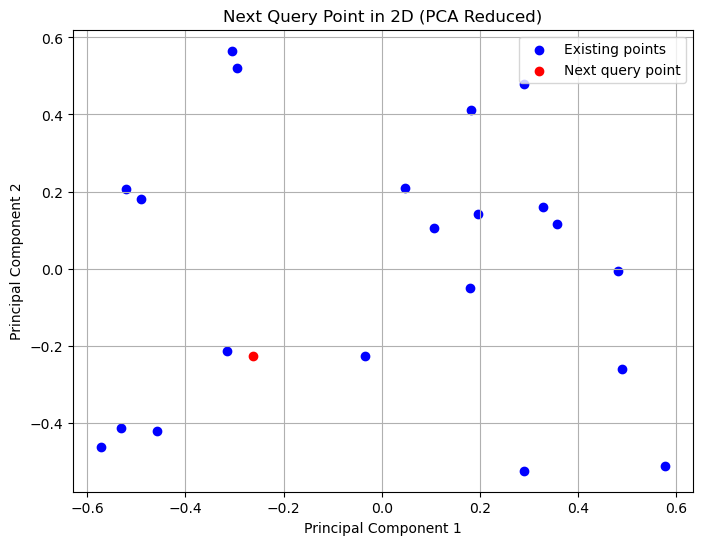

Next query point in 5D: [0.21872324 0.27704564 0.19639191 0.8442079  0.10032874]


In [369]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.decomposition import PCA
from scipy.stats import norm

# Step 1: Define the input and output data for the cake recipe optimization (function 6)
X_train = np.array([[0.7281861 , 0.15469257, 0.73255167, 0.69399651, 0.05640131],
                    [0.24238435, 0.84409997, 0.57780910, 0.67902128, 0.50195289],
                    [0.72952261, 0.74810620, 0.67977464, 0.35655228, 0.67105368],
                    [0.77062024, 0.11440374, 0.04677993, 0.64832428, 0.27354905],
                    [0.61881230, 0.33180214, 0.18728787, 0.75623847, 0.32883480],
                    [0.78495809, 0.91068235, 0.70812010, 0.95922543, 0.00491150],
                    [0.14511079, 0.89668460, 0.89632223, 0.72627154, 0.23627199],
                    [0.94506907, 0.28845905, 0.97880576, 0.96165559, 0.59801594],
                    [0.12572016, 0.86272469, 0.02854433, 0.24660527, 0.75120624],
                    [0.75759436, 0.35583141, 0.01652290, 0.43420720, 0.11243304],
                    [0.53679690, 0.30878091, 0.41187929, 0.38822518, 0.52252830],
                    [0.95773967, 0.23566857, 0.09914585, 0.15680593, 0.07131737],
                    [0.62930790, 0.80348368, 0.81140844, 0.04561319, 0.11062446],
                    [0.02173531, 0.42808424, 0.83593944, 0.48948866, 0.51108173],
                    [0.43934426, 0.69892383, 0.42682022, 0.10947609, 0.87788847],
                    [0.25890557, 0.79367771, 0.64211390, 0.19667346, 0.59310318],
                    [0.43216593, 0.71561781, 0.34181910, 0.70499988, 0.61496184],
                    [0.78287982, 0.53633586, 0.44328356, 0.85969983, 0.01032599],
                    [0.92177620, 0.93187122, 0.41487637, 0.59505727, 0.73562569],
                    [0.12667892, 0.29147030, 0.06452848, 0.68051460, 0.89281919],
                    [0.864822, 0.772164, 0.803941, 0.780551, 0.909036]])

y_train = np.array([-0.71426495, -1.20995524, -1.67219994, -1.53605771, -0.82923655,
                    -1.24704893, -1.23378638, -1.69434344, -2.57116963, -1.30911635,
                    -1.14478485, -1.91267714, -1.62283895, -1.35668211, -2.01842540,
                    -1.70255784, -1.29424696, -0.93575656, -2.15576776, -1.74688209,
                    -1.8405636029585657])

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))  # Constant kernel * RBF kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)

# Step 3: Fit the GP model to the existing data
gp.fit(X_train, y_train)

# Step 4: Define the UCB acquisition function with boundary penalty
def ucb_with_penalty(x, model, X_train, y_train, kappa=2.0, bounds=None, penalty_factor=100):  #reduce kappa from 2.5 to 2.0 to account for penalty around boundary
    """
    Upper Confidence Bound (UCB) acquisition function with penalty for boundary points.
    
    x: The point at which to evaluate the acquisition function
    model: The trained GaussianProcessRegressor model
    X_train: The previously evaluated points
    y_train: The previously observed values
    kappa: Exploration-exploitation trade-off parameter (larger kappa = more exploration)
    bounds: Tuple of (lower_bound, upper_bound) for each dimension
    penalty_factor: A factor by which to penalize points close to the boundary
    """
    # Reshape x to ensure it's a row vector
    x = np.array(x).reshape(1, -1)
    
    # Predict the mean and standard deviation at the new point
    mu, sigma = model.predict(x, return_std=True)
    
    # Calculate the UCB value
    ucb_value = mu + kappa * sigma
    
    # Penalize points near the boundary
    if bounds is not None:
        penalty = 0
        for i in range(len(x[0])):
            # Apply a penalty when a point is close to the boundary
            if x[0][i] < bounds[i][0] + 0.1 * (bounds[i][1] - bounds[i][0]) or x[0][i] > bounds[i][1] - 0.1 * (bounds[i][1] - bounds[i][0]):
                penalty += penalty_factor
        
        # Apply the penalty to UCB (more penalty = less attractive)
        ucb_value -= penalty
    
    return -ucb_value  # Minimize, so negate the UCB

# Step 5: Optimize the acquisition function to find the next query point
def optimize_acquisition_with_penalty(model, X_train, y_train, kappa=2.0, bounds=None):  #Reduce kappa from 2.5 to 2.0 to account for penalty around boundary
    # Random starting point for optimization within bounds
    x0 = np.random.uniform(0, 1, size=(1, X_train.shape[1]))
    
    # Optimize the acquisition function with penalty
    res = minimize(ucb_with_penalty, x0, args=(model, X_train, y_train, kappa, bounds),
                   bounds=bounds)
    
    # Get the new query point
    new_x = res.x
    return new_x

# Step 6: Define the bounds for each dimension
bounds = [(0, 1), (0, 1), (0, 1), (0, 1), (0, 1)]  # 5D space, all between 0 and 1

# Step 7: Find the next query point
next_query_point = optimize_acquisition_with_penalty(gp, X_train, y_train, kappa=2.0, bounds=bounds)

# Step 8: Visualize the next query point in 2D using PCA (since we have 5D data)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)  # Reduce dimensionality to 2D

# Step 9: Plot the existing points and the next query point
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], color='blue', label='Existing points')
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))  # Transform the next query point to 2D
plt.scatter(next_query_point_pca[:, 0], next_query_point_pca[:, 1], color='red', label='Next query point')

plt.title('Next Query Point in 2D (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Print the next query point in 5D
print("Next query point in 5D:", next_query_point)

### Function 7

#### Using EI acquisition

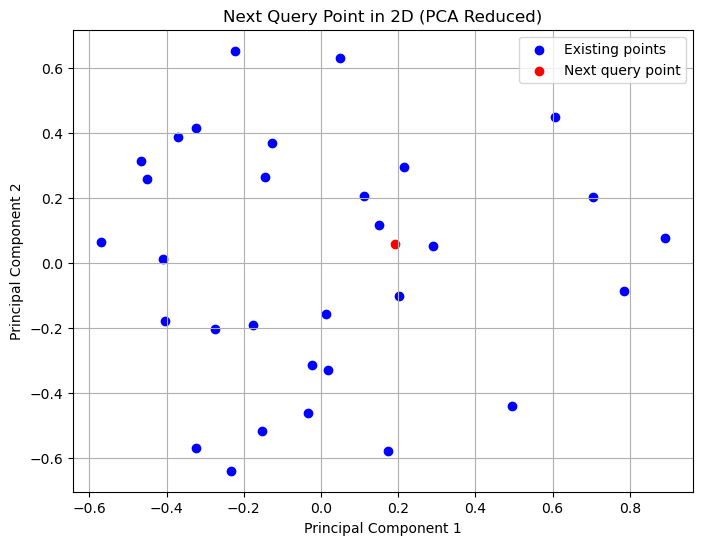

Next query point in 6D: [0.01125334 0.31586487 0.34113946 0.13450941 0.34555837 0.73651181]


In [451]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.decomposition import PCA

# Step 1: Define the input and output data for function 7 (ML hyperparameter optimization)
X_train = np.array([[0.27262382, 0.32449536, 0.89710881, 0.83295115, 0.15406269, 0.79586362],
                    [0.54300258, 0.92469390, 0.34156746, 0.64648585, 0.71844033, 0.34313266],
                    [0.09083225, 0.66152938, 0.06593091, 0.25857701, 0.96345285, 0.64026540],
                    [0.11886697, 0.61505494, 0.90581639, 0.85530030, 0.41363143, 0.58523563],
                    [0.63021764, 0.83809690, 0.68001305, 0.73189509, 0.52673671, 0.34842921],
                    [0.76491917, 0.25588292, 0.60908422, 0.21807904, 0.32294277, 0.09579366],
                    [0.05789554, 0.49167222, 0.24742222, 0.21811844, 0.42042833, 0.73096984],
                    [0.19525188, 0.07922665, 0.55458046, 0.17056682, 0.01494418, 0.10703171],
                    [0.64230298, 0.83687455, 0.02179269, 0.10148801, 0.68307083, 0.69241640],
                    [0.78994255, 0.19554501, 0.57562333, 0.07365919, 0.25904917, 0.05109986],
                    [0.52849733, 0.45742436, 0.36009569, 0.36204551, 0.81689098, 0.63747637],
                    [0.72261522, 0.01181284, 0.06364591, 0.16517311, 0.07924415, 0.35995166],
                    [0.07566492, 0.33450212, 0.13273274, 0.60831236, 0.91838592, 0.82233079],
                    [0.94245084, 0.37743962, 0.48612233, 0.22879108, 0.08263175, 0.71195755],
                    [0.14864702, 0.03394336, 0.72880565, 0.31606646, 0.02176938, 0.51691776],
                    [0.81711239, 0.54816823, 0.10334758, 0.12436955, 0.72823482, 0.44967361],
                    [0.41762629, 0.06409998, 0.24566877, 0.55904080, 0.19153138, 0.25464092],
                    [0.72628566, 0.46489581, 0.92457051, 0.80724540, 0.63543840, 0.14341787],
                    [0.31981043, 0.52009759, 0.29067775, 0.87670668, 0.49503469, 0.61908250],
                    [0.87987128, 0.39796199, 0.00363456, 0.95699064, 0.26451373, 0.11486924],
                    [0.54124078, 0.63140314, 0.03190205, 0.44998156, 0.79865282, 0.63370429],
                    [0.22634792, 0.11502581, 0.82474966, 0.94538372, 0.90531153, 0.95101392],
                    [0.68685257, 0.04101721, 0.00757301, 0.28500900, 0.69156848, 0.65554290],
                    [0.17597754, 0.62441650, 0.29554198, 0.46955276, 0.09776977, 0.72814108],
                    [0.88164674, 0.20445019, 0.41447436, 0.42038468, 0.26491501, 0.73066019],
                    [0.06661051, 0.52804507, 0.81609520, 0.96101714, 0.08650933, 0.77778822],
                    [0.93246638, 0.48881189, 0.25860774, 0.95624344, 0.19042781, 0.51985176],
                    [0.84686697, 0.14242917, 0.06066859, 0.75629213, 0.55239830, 0.08130609],
                    [0.80628208, 0.32412237, 0.72607601, 0.14871213, 0.71937640, 0.36288398],
                    [0.47682313, 0.34094195, 0.01433523, 0.88013956, 0.99865470, 0.07966402],
                    [0.432685, 0.656678, 0.117406, 0.355722, 0.832462, 0.072554]])

y_train = np.array([0.6044327 , 0.56275307, 0.00750324, 0.06142430, 0.27304680,
                    0.08374657, 1.36496830, 0.09264495, 0.01786960, 0.03356494,
                    0.07351630, 0.20630970, 0.00882563, 0.26840032, 0.61152553,
                    0.01479818, 0.27489251, 0.06676325, 0.04211835, 0.00270147,
                    0.01820907, 0.00701603, 0.10050661, 0.47539552, 0.67514163,
                    0.51645722, 0.00377748, 0.00313433, 0.02134252, 0.09541116,
                    1.1810801774433033])

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))  # Constant kernel * RBF kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)

# Step 3: Fit the GP model to the existing data
gp.fit(X_train, y_train)

# Step 4: Define the Expected Improvement (EI) acquisition function with exploration
def expected_improvement(x, model, X_train, y_train, xi=0.1):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    y_best = np.max(y_train)  # Maximization problem
    improvement = mu - y_best - xi  # Subtract xi for exploration
    ei = improvement * norm.cdf(improvement / sigma) + sigma * norm.pdf(improvement / sigma)
    return -ei  # Minimize the acquisition function

# Step 5: Optimize the acquisition function to find the next query point
def optimize_acquisition(model, X_train, y_train, length=0.5, xi=0.1):
    # Random starting point for optimization
    x0 = np.random.uniform(0, 1, size=(1, 6))
    
    # Optimize the acquisition function
    res = minimize(expected_improvement, x0, args=(model, X_train, y_train, xi),
                   bounds=[(0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1)])
    
    # Get the new query point
    new_x = res.x
    return new_x

# Step 6: Find the next query point
next_query_point = optimize_acquisition(gp, X_train, y_train)

# Step 7: Visualize the next query point in 2D using PCA (since we have 6D data)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)  # Reduce dimensionality to 2D

# Step 8: Plot the existing points and the next query point
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], color='blue', label='Existing points')
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))  # Transform the next query point to 2D
plt.scatter(next_query_point_pca[:, 0], next_query_point_pca[:, 1], color='red', label='Next query point')

plt.title('Next Query Point in 2D (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Print the next query point in 6D
print("Next query point in 6D:", next_query_point)

#### Using UCB acquisition 

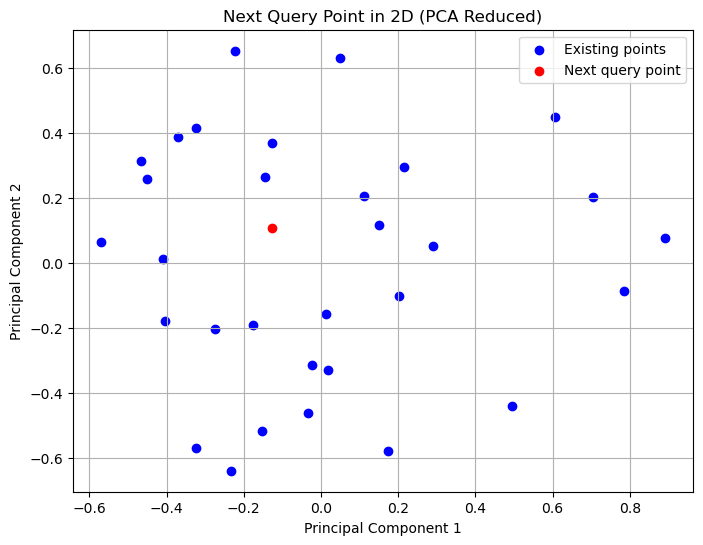

Next query point in 6D: [0.06451227 0.62873835 0.20804726 0.15108081 0.45904404 0.21584273]


In [477]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.decomposition import PCA

# Step 1: Define the input and output data for function 7 (ML hyperparameter optimization)
X_train = np.array([[0.27262382, 0.32449536, 0.89710881, 0.83295115, 0.15406269, 0.79586362],
                    [0.54300258, 0.92469390, 0.34156746, 0.64648585, 0.71844033, 0.34313266],
                    [0.09083225, 0.66152938, 0.06593091, 0.25857701, 0.96345285, 0.64026540],
                    [0.11886697, 0.61505494, 0.90581639, 0.85530030, 0.41363143, 0.58523563],
                    [0.63021764, 0.83809690, 0.68001305, 0.73189509, 0.52673671, 0.34842921],
                    [0.76491917, 0.25588292, 0.60908422, 0.21807904, 0.32294277, 0.09579366],
                    [0.05789554, 0.49167222, 0.24742222, 0.21811844, 0.42042833, 0.73096984],
                    [0.19525188, 0.07922665, 0.55458046, 0.17056682, 0.01494418, 0.10703171],
                    [0.64230298, 0.83687455, 0.02179269, 0.10148801, 0.68307083, 0.69241640],
                    [0.78994255, 0.19554501, 0.57562333, 0.07365919, 0.25904917, 0.05109986],
                    [0.52849733, 0.45742436, 0.36009569, 0.36204551, 0.81689098, 0.63747637],
                    [0.72261522, 0.01181284, 0.06364591, 0.16517311, 0.07924415, 0.35995166],
                    [0.07566492, 0.33450212, 0.13273274, 0.60831236, 0.91838592, 0.82233079],
                    [0.94245084, 0.37743962, 0.48612233, 0.22879108, 0.08263175, 0.71195755],
                    [0.14864702, 0.03394336, 0.72880565, 0.31606646, 0.02176938, 0.51691776],
                    [0.81711239, 0.54816823, 0.10334758, 0.12436955, 0.72823482, 0.44967361],
                    [0.41762629, 0.06409998, 0.24566877, 0.55904080, 0.19153138, 0.25464092],
                    [0.72628566, 0.46489581, 0.92457051, 0.80724540, 0.63543840, 0.14341787],
                    [0.31981043, 0.52009759, 0.29067775, 0.87670668, 0.49503469, 0.61908250],
                    [0.87987128, 0.39796199, 0.00363456, 0.95699064, 0.26451373, 0.11486924],
                    [0.54124078, 0.63140314, 0.03190205, 0.44998156, 0.79865282, 0.63370429],
                    [0.22634792, 0.11502581, 0.82474966, 0.94538372, 0.90531153, 0.95101392],
                    [0.68685257, 0.04101721, 0.00757301, 0.28500900, 0.69156848, 0.65554290],
                    [0.17597754, 0.62441650, 0.29554198, 0.46955276, 0.09776977, 0.72814108],
                    [0.88164674, 0.20445019, 0.41447436, 0.42038468, 0.26491501, 0.73066019],
                    [0.06661051, 0.52804507, 0.81609520, 0.96101714, 0.08650933, 0.77778822],
                    [0.93246638, 0.48881189, 0.25860774, 0.95624344, 0.19042781, 0.51985176],
                    [0.84686697, 0.14242917, 0.06066859, 0.75629213, 0.55239830, 0.08130609],
                    [0.80628208, 0.32412237, 0.72607601, 0.14871213, 0.71937640, 0.36288398],
                    [0.47682313, 0.34094195, 0.01433523, 0.88013956, 0.99865470, 0.07966402],
                    [0.432685, 0.656678, 0.117406, 0.355722, 0.832462, 0.072554]])

y_train = np.array([0.6044327 , 0.56275307, 0.00750324, 0.06142430, 0.27304680,
                    0.08374657, 1.36496830, 0.09264495, 0.01786960, 0.03356494,
                    0.07351630, 0.20630970, 0.00882563, 0.26840032, 0.61152553,
                    0.01479818, 0.27489251, 0.06676325, 0.04211835, 0.00270147,
                    0.01820907, 0.00701603, 0.10050661, 0.47539552, 0.67514163,
                    0.51645722, 0.00377748, 0.00313433, 0.02134252, 0.09541116,
                    1.18108018])

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))  # Constant kernel * RBF kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)

# Step 3: Fit the GP model to the existing data
gp.fit(X_train, y_train)

# Step 4: Define the Upper Confidence Bound (UCB) acquisition function
def upper_confidence_bound(x, model, kappa=5.0):  #Increase kappa from 2.5 to 5.0 to avoid getting stuck in local optima
    """
    Upper Confidence Bound (UCB) acquisition function.
    x: The point at which to evaluate the acquisition function
    model: The trained GaussianProcessRegressor model
    kappa: Exploration-exploitation trade-off parameter (larger kappa = more exploration)
    """
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    ucb = mu + kappa * sigma
    return -ucb  # Minimize the negative UCB

# Step 5: Optimize the acquisition function to find the next query point
def optimize_acquisition(model, X_train, y_train, length=0.5, kappa=5.0):
    # Random starting point for optimization
    x0 = np.random.uniform(0, 1, size=(1, X_train.shape[1]))
    
    # Optimize the acquisition function
    res = minimize(upper_confidence_bound, x0, args=(model, kappa),
                   bounds=[(0, 1)] * X_train.shape[1])
    
    # Get the new query point
    new_x = res.x
    return new_x

# Step 6: Find the next query point
next_query_point = optimize_acquisition(gp, X_train, y_train, kappa=5.0)

# Step 7: Visualize the next query point in 2D using PCA (since we have 6D data)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)  # Reduce dimensionality to 2D

# Step 8: Plot the existing points and the next query point
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], color='blue', label='Existing points')
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))  # Transform the next query point to 2D
plt.scatter(next_query_point_pca[:, 0], next_query_point_pca[:, 1], color='red', label='Next query point')

plt.title('Next Query Point in 2D (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Print the next query point in 6D
print("Next query point in 6D:", next_query_point)

### Function 8

#### Using EI acquisition

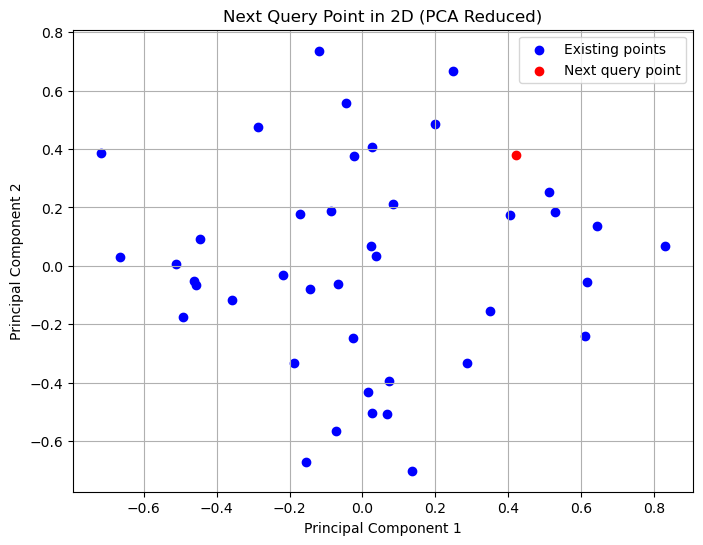

Next query point in 8D: [0.53320876 0.89848542 0.66939491 0.11287383 0.94641921 0.10809161
 0.2632889  0.34544493]


In [544]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.decomposition import PCA

# Step 1: Define the input and output data for function 8 (ML hyperparameter optimization)
X_train = np.array([[0.60499445, 0.29221502, 0.90845275, 0.35550624, 0.20166872,
        0.57533801, 0.31031095, 0.73428138],
       [0.17800696, 0.56622265, 0.99486184, 0.21032501, 0.32015266,
        0.70790879, 0.63538449, 0.10713163],
       [0.00907698, 0.81162615, 0.52052036, 0.07568668, 0.26511183,
        0.09165169, 0.59241515, 0.36732026],
       [0.50602816, 0.65373012, 0.36341078, 0.17798105, 0.09372830,
        0.19742533, 0.75582690, 0.29247234],
       [0.35990926, 0.24907568, 0.49599717, 0.70921498, 0.11498719,
        0.28920692, 0.55729515, 0.59388173],
       [0.77881834, 0.00341950, 0.33798313, 0.51952778, 0.82090699,
        0.53724669, 0.55134710, 0.66003209],
       [0.90864932, 0.06224970, 0.23825955, 0.76660355, 0.13233596,
        0.99024381, 0.68806782, 0.74249594],
       [0.58637144, 0.88073573, 0.74502075, 0.54603485, 0.00964888,
        0.74899176, 0.23090707, 0.09791562],
       [0.76113733, 0.85467239, 0.38212433, 0.33735198, 0.68970832,
        0.30985305, 0.63137968, 0.04195607],
       [0.98493320, 0.69950626, 0.99888550, 0.18014846, 0.58014315,
        0.23108719, 0.49082694, 0.31368272],
       [0.11207131, 0.43773566, 0.59659878, 0.59277563, 0.22698177,
        0.41010452, 0.92123758, 0.67475276],
       [0.79188751, 0.57619134, 0.69452836, 0.28342378, 0.13675546,
        0.27916186, 0.84276726, 0.62532792],
       [0.14355030, 0.93741452, 0.23232482, 0.00904349, 0.41457893,
        0.40932517, 0.55377852, 0.20584080],
       [0.76991655, 0.45875909, 0.55900044, 0.69460444, 0.50319902,
        0.72834638, 0.78425353, 0.66313109],
       [0.05644741, 0.06595555, 0.02292868, 0.03878647, 0.40393544,
        0.80105533, 0.48830701, 0.89308498],
       [0.86243745, 0.48273382, 0.28186940, 0.54410223, 0.88749026,
        0.38265469, 0.60190199, 0.47646169],
       [0.35151190, 0.59006494, 0.90943630, 0.67840835, 0.21282566,
        0.08846038, 0.41015300, 0.19572429],
       [0.73590364, 0.03461189, 0.72803027, 0.14742652, 0.29574314,
        0.44511731, 0.97517969, 0.37433978],
       [0.68029397, 0.25510465, 0.86218799, 0.13439582, 0.32632920,
        0.28790687, 0.43501048, 0.36420013],
       [0.04432925, 0.01358149, 0.25819824, 0.57764416, 0.05127992,
        0.15856307, 0.59103012, 0.07795293],
       [0.77834548, 0.75114565, 0.31414221, 0.90298577, 0.33538166,
        0.38632267, 0.74897249, 0.98875510],
       [0.89888711, 0.52364170, 0.87678325, 0.21869645, 0.90026089,
        0.28276624, 0.91107791, 0.47239822],
       [0.14512029, 0.11932754, 0.42088822, 0.38760861, 0.15542283,
        0.87517163, 0.51055967, 0.72861058],
       [0.33895442, 0.56693202, 0.37675110, 0.09891573, 0.65945169,
        0.24554809, 0.76248278, 0.73215347],
       [0.17615002, 0.29396143, 0.97567997, 0.79393631, 0.92340076,
        0.03084229, 0.80325452, 0.59589758],
       [0.02894663, 0.02827906, 0.48137155, 0.61317460, 0.67266045,
        0.02211341, 0.60148330, 0.52488505],
       [0.19263987, 0.63067728, 0.41679584, 0.49052929, 0.79608602,
        0.65456706, 0.27624119, 0.29551759],
       [0.94318502, 0.21885062, 0.72118408, 0.42459707, 0.98690200,
        0.53518298, 0.71474318, 0.96009372],
       [0.53272140, 0.83369260, 0.07139900, 0.11681148, 0.73069311,
        0.93737559, 0.86650798, 0.12790200],
       [0.44709584, 0.84395253, 0.72954612, 0.63915138, 0.40928714,
        0.13264569, 0.03590888, 0.44683847],
       [0.38222497, 0.55713584, 0.85310163, 0.33379569, 0.26572127,
        0.48087292, 0.23764706, 0.76863196],
       [0.53281953, 0.86230848, 0.53826712, 0.04944293, 0.71970119,
        0.90670590, 0.10823094, 0.52534791],
       [0.39486519, 0.33180167, 0.74075430, 0.69786172, 0.73740444,
        0.78377681, 0.25449546, 0.87114551],
       [0.98594539, 0.87305363, 0.07039262, 0.05358729, 0.73415296,
        0.52025852, 0.81104004, 0.10336036],
       [0.96457339, 0.97397979, 0.66375335, 0.66221599, 0.67312167,
        0.90523762, 0.45887462, 0.56091750],
       [0.47207071, 0.16820264, 0.08642757, 0.45265551, 0.48061922,
        0.62243949, 0.92897446, 0.11253627],
       [0.85600695, 0.63889370, 0.32619202, 0.66850311, 0.24029837,
        0.21029889, 0.16754636, 0.96358986],
       [0.81003174, 0.63504604, 0.26954758, 0.86960534, 0.66192159,
        0.25225873, 0.76567003, 0.89054867],
       [0.79625252, 0.00703653, 0.35569738, 0.48756605, 0.74051962,
        0.70665010, 0.99291449, 0.38173437],
       [0.48124533, 0.10246072, 0.21948594, 0.67732237, 0.24750919,
        0.24434086, 0.16382453, 0.71596164],
        [0.895434, 0.912022, 0.098160, 0.036667, 0.445138, 0.679791, 0.229544, 0.761742]])  

y_train = np.array([7.3987211 , 7.00522736, 8.45948162, 8.28400781, 8.60611679,
                    8.54174792, 7.32743458, 7.29987205, 7.95787474, 5.59219339,
                    7.85454099, 6.79198578, 8.97655402, 7.37908290, 9.59848200,
                    8.15998319, 7.13162397, 6.76796253, 7.43374407, 9.01307515,
                    7.31089382, 5.84106731, 9.14163949, 8.81755844, 6.45194313,
                    8.83074505, 9.34427428, 6.88784639, 8.04221254, 7.69236805,
                    7.92375877, 8.42175924, 8.27806240, 7.11345716, 6.40258841,
                    8.47293632, 7.97768459, 7.46087219, 7.43659353, 9.18300525,
                    8.0383561825836])

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))  # Constant kernel * RBF kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)

# Step 3: Fit the GP model to the existing data
gp.fit(X_train, y_train)

# Step 4: Define the Expected Improvement (EI) acquisition function with exploration
def expected_improvement(x, model, X_train, y_train, xi=0.2):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    y_best = np.max(y_train)  # Maximization problem
    improvement = mu - y_best - xi  # Subtract xi for exploration
    ei = improvement * norm.cdf(improvement / sigma) + sigma * norm.pdf(improvement / sigma)
    return -ei  # Minimize the acquisition function

# Step 5: Optimize the acquisition function to find the next query point
def optimize_acquisition(model, X_train, y_train, length=0.5, xi=0.1):
    # Random starting point for optimization
    x0 = np.random.uniform(0, 1, size=(1, 8))
    
    # Optimize the acquisition function
    res = minimize(expected_improvement, x0, args=(model, X_train, y_train, xi),
                   bounds=[(0, 1)] * 8)  # 8D bounds
    
    # Get the new query point
    new_x = res.x
    return new_x

# Step 6: Find the next query point
next_query_point = optimize_acquisition(gp, X_train, y_train)

# Step 7: Visualize the next query point in 2D using PCA (since we have 8D data)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)  # Reduce dimensionality to 2D

# Step 8: Plot the existing points and the next query point
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], color='blue', label='Existing points')
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))  # Transform the next query point to 2D
plt.scatter(next_query_point_pca[:, 0], next_query_point_pca[:, 1], color='red', label='Next query point')

plt.title('Next Query Point in 2D (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Print the next query point in 8D
print("Next query point in 8D:", next_query_point)

#### Using UCB acquisition

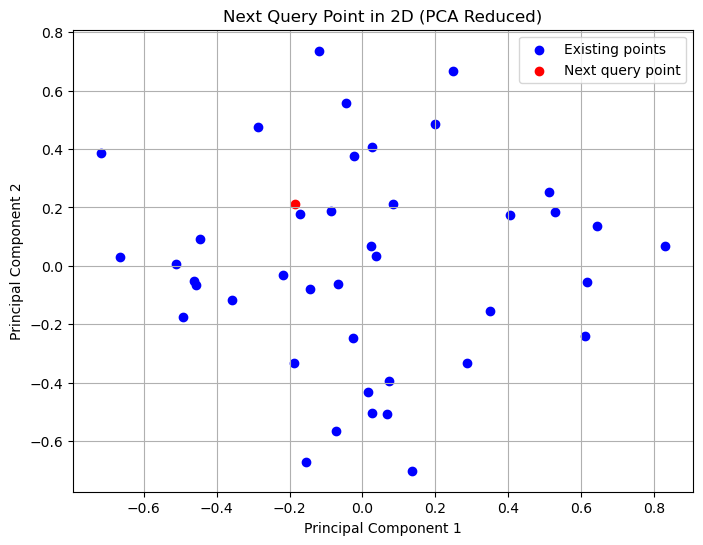

Next query point in 8D: [0.         0.10231944 0.         0.         1.         0.33752322
 0.         0.38157887]


In [554]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.decomposition import PCA

# Step 1: Define the input and output data for function 8 (ML hyperparameter optimization)
X_train = np.array([[0.60499445, 0.29221502, 0.90845275, 0.35550624, 0.20166872,
        0.57533801, 0.31031095, 0.73428138],
       [0.17800696, 0.56622265, 0.99486184, 0.21032501, 0.32015266,
        0.70790879, 0.63538449, 0.10713163],
       [0.00907698, 0.81162615, 0.52052036, 0.07568668, 0.26511183,
        0.09165169, 0.59241515, 0.36732026],
       [0.50602816, 0.65373012, 0.36341078, 0.17798105, 0.09372830,
        0.19742533, 0.75582690, 0.29247234],
       [0.35990926, 0.24907568, 0.49599717, 0.70921498, 0.11498719,
        0.28920692, 0.55729515, 0.59388173],
       [0.77881834, 0.00341950, 0.33798313, 0.51952778, 0.82090699,
        0.53724669, 0.55134710, 0.66003209],
       [0.90864932, 0.06224970, 0.23825955, 0.76660355, 0.13233596,
        0.99024381, 0.68806782, 0.74249594],
       [0.58637144, 0.88073573, 0.74502075, 0.54603485, 0.00964888,
        0.74899176, 0.23090707, 0.09791562],
       [0.76113733, 0.85467239, 0.38212433, 0.33735198, 0.68970832,
        0.30985305, 0.63137968, 0.04195607],
       [0.98493320, 0.69950626, 0.99888550, 0.18014846, 0.58014315,
        0.23108719, 0.49082694, 0.31368272],
       [0.11207131, 0.43773566, 0.59659878, 0.59277563, 0.22698177,
        0.41010452, 0.92123758, 0.67475276],
       [0.79188751, 0.57619134, 0.69452836, 0.28342378, 0.13675546,
        0.27916186, 0.84276726, 0.62532792],
       [0.14355030, 0.93741452, 0.23232482, 0.00904349, 0.41457893,
        0.40932517, 0.55377852, 0.20584080],
       [0.76991655, 0.45875909, 0.55900044, 0.69460444, 0.50319902,
        0.72834638, 0.78425353, 0.66313109],
       [0.05644741, 0.06595555, 0.02292868, 0.03878647, 0.40393544,
        0.80105533, 0.48830701, 0.89308498],
       [0.86243745, 0.48273382, 0.28186940, 0.54410223, 0.88749026,
        0.38265469, 0.60190199, 0.47646169],
       [0.35151190, 0.59006494, 0.90943630, 0.67840835, 0.21282566,
        0.08846038, 0.41015300, 0.19572429],
       [0.73590364, 0.03461189, 0.72803027, 0.14742652, 0.29574314,
        0.44511731, 0.97517969, 0.37433978],
       [0.68029397, 0.25510465, 0.86218799, 0.13439582, 0.32632920,
        0.28790687, 0.43501048, 0.36420013],
       [0.04432925, 0.01358149, 0.25819824, 0.57764416, 0.05127992,
        0.15856307, 0.59103012, 0.07795293],
       [0.77834548, 0.75114565, 0.31414221, 0.90298577, 0.33538166,
        0.38632267, 0.74897249, 0.98875510],
       [0.89888711, 0.52364170, 0.87678325, 0.21869645, 0.90026089,
        0.28276624, 0.91107791, 0.47239822],
       [0.14512029, 0.11932754, 0.42088822, 0.38760861, 0.15542283,
        0.87517163, 0.51055967, 0.72861058],
       [0.33895442, 0.56693202, 0.37675110, 0.09891573, 0.65945169,
        0.24554809, 0.76248278, 0.73215347],
       [0.17615002, 0.29396143, 0.97567997, 0.79393631, 0.92340076,
        0.03084229, 0.80325452, 0.59589758],
       [0.02894663, 0.02827906, 0.48137155, 0.61317460, 0.67266045,
        0.02211341, 0.60148330, 0.52488505],
       [0.19263987, 0.63067728, 0.41679584, 0.49052929, 0.79608602,
        0.65456706, 0.27624119, 0.29551759],
       [0.94318502, 0.21885062, 0.72118408, 0.42459707, 0.98690200,
        0.53518298, 0.71474318, 0.96009372],
       [0.53272140, 0.83369260, 0.07139900, 0.11681148, 0.73069311,
        0.93737559, 0.86650798, 0.12790200],
       [0.44709584, 0.84395253, 0.72954612, 0.63915138, 0.40928714,
        0.13264569, 0.03590888, 0.44683847],
       [0.38222497, 0.55713584, 0.85310163, 0.33379569, 0.26572127,
        0.48087292, 0.23764706, 0.76863196],
       [0.53281953, 0.86230848, 0.53826712, 0.04944293, 0.71970119,
        0.90670590, 0.10823094, 0.52534791],
       [0.39486519, 0.33180167, 0.74075430, 0.69786172, 0.73740444,
        0.78377681, 0.25449546, 0.87114551],
       [0.98594539, 0.87305363, 0.07039262, 0.05358729, 0.73415296,
        0.52025852, 0.81104004, 0.10336036],
       [0.96457339, 0.97397979, 0.66375335, 0.66221599, 0.67312167,
        0.90523762, 0.45887462, 0.56091750],
       [0.47207071, 0.16820264, 0.08642757, 0.45265551, 0.48061922,
        0.62243949, 0.92897446, 0.11253627],
       [0.85600695, 0.63889370, 0.32619202, 0.66850311, 0.24029837,
        0.21029889, 0.16754636, 0.96358986],
       [0.81003174, 0.63504604, 0.26954758, 0.86960534, 0.66192159,
        0.25225873, 0.76567003, 0.89054867],
       [0.79625252, 0.00703653, 0.35569738, 0.48756605, 0.74051962,
        0.70665010, 0.99291449, 0.38173437],
       [0.48124533, 0.10246072, 0.21948594, 0.67732237, 0.24750919,
        0.24434086, 0.16382453, 0.71596164],
       [0.895434, 0.912022, 0.098160, 0.036667, 0.445138, 0.679791, 0.229544, 0.761742]])  

y_train = np.array([7.3987211 , 7.00522736, 8.45948162, 8.28400781, 8.60611679,
                    8.54174792, 7.32743458, 7.29987205, 7.95787474, 5.59219339,
                    7.85454099, 6.79198578, 8.97655402, 7.37908290, 9.59848200,
                    8.15998319, 7.13162397, 6.76796253, 7.43374407, 9.01307515,
                    7.31089382, 5.84106731, 9.14163949, 8.81755844, 6.45194313,
                    8.83074505, 9.34427428, 6.88784639, 8.04221254, 7.69236805,
                    7.92375877, 8.42175924, 8.27806240, 7.11345716, 6.40258841,
                    8.47293632, 7.97768459, 7.46087219, 7.43659353, 9.18300525,
                    8.0383561825836])

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))  # Constant kernel * RBF kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)

# Step 3: Fit the GP model to the existing data
gp.fit(X_train, y_train)

# Step 4: Define the Upper Confidence Bound (UCB) acquisition function
def upper_confidence_bound(x, model, kappa=2.0):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    ucb = mu + kappa * sigma  # Maximizing UCB
    return -ucb  # Minimize the negative UCB

# Step 5: Optimize the acquisition function to find the next query point
def optimize_acquisition(model, X_train, y_train, length=0.5, kappa=2.0):
    # Random starting point for optimization
    x0 = np.random.uniform(0, 1, size=(1, 8))
    
    # Optimize the acquisition function
    res = minimize(upper_confidence_bound, x0, args=(model, kappa),
                   bounds=[(0, 1)] * 8)  # 8D bounds
    
    # Get the new query point
    new_x = res.x
    return new_x

# Step 6: Find the next query point
next_query_point = optimize_acquisition(gp, X_train, y_train)

# Step 7: Visualize the next query point in 2D using PCA (since we have 8D data)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)  # Reduce dimensionality to 2D

# Step 8: Plot the existing points and the next query point
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], color='blue', label='Existing points')
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))  # Transform the next query point to 2D
plt.scatter(next_query_point_pca[:, 0], next_query_point_pca[:, 1], color='red', label='Next query point')

plt.title('Next Query Point in 2D (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Print the next query point in 8D
print("Next query point in 8D:", next_query_point)